In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [255]:
users=pd.read_excel(r"C:\Users\HOME\Desktop\project#3\users.xlsx")
events=pd.read_excel(r"C:\Users\HOME\Desktop\project#3\events.xlsx")

In [256]:
users.shape

(5000, 2)

In [257]:
events.shape

(27291, 3)

In [258]:
users.head()

,user_id,install_date
0,1,2024-01-07
1,2,2024-01-20
2,3,2024-01-29
3,4,2024-01-15
4,5,2024-01-11


In [259]:
events.head()

,user_id,event_date,event_type
0,1,2024-01-07,session_start
1,1,2024-01-08,session_start
2,1,2024-01-09,session_start
3,1,2024-01-10,session_start
4,1,2024-01-11,session_start


In [260]:
users.columns.tolist()

['user_id', 'install_date']

In [261]:
events.columns.tolist()

['user_id', 'event_date', 'event_type']

In [262]:
users.dtypes

user_id                  int64
install_date    datetime64[us]
dtype: object

In [263]:
events.dtypes

user_id                int64
event_date    datetime64[us]
event_type               str
dtype: object

In [264]:
users["install_date"] = pd.to_datetime(users["install_date"])
events["event_date"] = pd.to_datetime(events["event_date"])

In [265]:
users.head(10)

,user_id,install_date
0,1,2024-01-07
1,2,2024-01-20
2,3,2024-01-29
3,4,2024-01-15
4,5,2024-01-11
5,6,2024-01-08
6,7,2024-01-29
7,8,2024-01-21
8,9,2024-01-07
9,10,2024-01-26


In [266]:
events.head(10)

,user_id,event_date,event_type
0,1,2024-01-07,session_start
1,1,2024-01-08,session_start
2,1,2024-01-09,session_start
3,1,2024-01-10,session_start
4,1,2024-01-11,session_start
5,1,2024-01-12,session_start
6,2,2024-01-20,session_start
7,2,2024-01-21,session_start
8,2,2024-01-22,session_start
9,2,2024-01-23,session_start


In [267]:
users.isnull().sum()

user_id         0
install_date    0
dtype: int64

In [268]:
events.isnull().sum()

user_id       0
event_date    0
event_type    0
dtype: int64

In [269]:
users.duplicated().sum()

np.int64(0)

In [270]:
events.duplicated().sum()

np.int64(0)

In [271]:
users["user_id"].nunique()

5000

In [272]:
print(
    "Duplicate user IDs:",
    users["user_id"].duplicated().sum()
)

Duplicate user IDs: 0


In [273]:
print("Unique event users:", events["user_id"].nunique())

Unique event users: 5000


In [274]:
#checking refrential integrity
unknown_event_users = set(events["user_id"]) - set(users["user_id"])
print("Events with unknown users:", len(unknown_event_users))

Events with unknown users: 0


In [275]:
events["event_type"].value_counts()

event_type
session_start    27291
Name: count, dtype: int64

In [276]:
print("Install date range:")
print(users["install_date"].min())
print(users["install_date"].max())

Install date range:
2024-01-01 00:00:00
2024-01-30 00:00:00


In [277]:
print("Event date range:")
print(events["event_date"].min())
print(events["event_date"].max())

Event date range:
2024-01-01 00:00:00
2024-03-05 00:00:00


In [278]:
#checking if a player has a game-session event before installing the game.
master_events = events.merge(users,on="user_id",how="left")
master_events.head()

,user_id,event_date,event_type,install_date
0,1,2024-01-07,session_start,2024-01-07
1,1,2024-01-08,session_start,2024-01-07
2,1,2024-01-09,session_start,2024-01-07
3,1,2024-01-10,session_start,2024-01-07
4,1,2024-01-11,session_start,2024-01-07


In [279]:
master_events["install_date"].isnull().sum()

np.int64(0)

In [280]:
master_events["days_since_install"] = (
    master_events["event_date"]
    - master_events["install_date"]
).dt.days

negative_days = (
    master_events["days_since_install"] < 0
).sum()

print("Events before installation:", negative_days)

Events before installation: 0


In [281]:
master_events["days_since_install"].describe()


count    27291.000000
mean         4.468433
std          4.889124
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max         38.000000
Name: days_since_install, dtype: float64

In [282]:
same_day_events = (master_events.groupby(["user_id", "event_date"]).size())

print("Total player-day combinations:",
      len(same_day_events))

print("Player-days with multiple events:",
      (same_day_events > 1).sum())

print("Maximum events by one player on one day:",
      same_day_events.max())

Total player-day combinations: 27291
Player-days with multiple events: 0
Maximum events by one player on one day: 1


In [283]:
player_day = (
    master_events[
        ["user_id", "event_date", "days_since_install"]
    ]
    .drop_duplicates()
)

print("Player-day table shape:", player_day.shape)

display(player_day.head(10))

Player-day table shape: (27291, 3)


,user_id,event_date,days_since_install
0,1,2024-01-07,0
1,1,2024-01-08,1
2,1,2024-01-09,2
3,1,2024-01-10,3
4,1,2024-01-11,4
5,1,2024-01-12,5
6,2,2024-01-20,0
7,2,2024-01-21,1
8,2,2024-01-22,2
9,2,2024-01-23,3


In [284]:
sessions_per_player = (
    master_events
    .groupby("user_id")
    .size()
    .reset_index(name="total_sessions")
)

display(sessions_per_player.head())

,user_id,total_sessions
0,1,6
1,2,4
2,3,11
3,4,2
4,5,6


In [285]:
active_days_per_player = (
    master_events
    .groupby("user_id")["event_date"]
    .nunique()
    .reset_index(name="active_days")
)

display(active_days_per_player.head())

,user_id,active_days
0,1,6
1,2,4
2,3,11
3,4,2
4,5,6


In [286]:
player_summary = (
    sessions_per_player
    .merge(
        active_days_per_player,
        on="user_id",
        how="left"
    )
)

display(player_summary.head(10))

,user_id,total_sessions,active_days
0,1,6,6
1,2,4,4
2,3,11,11
3,4,2,2
4,5,6,6
5,6,5,5
6,7,2,2
7,8,1,1
8,9,6,6
9,10,7,7


In [287]:
player_summary["sessions_per_active_day"] = (
    player_summary["total_sessions"]
    / player_summary["active_days"]
)

display(player_summary.head(10))

,user_id,total_sessions,active_days,sessions_per_active_day
0,1,6,6,1.0
1,2,4,4,1.0
2,3,11,11,1.0
3,4,2,2,1.0
4,5,6,6,1.0
5,6,5,5,1.0
6,7,2,2,1.0
7,8,1,1,1.0
8,9,6,6,1.0
9,10,7,7,1.0


In [288]:
print(
    "Events before installation:",
    (master_events["days_since_install"] < 0).sum()
)

Events before installation: 0


In [289]:
daily_events = (
    master_events
    .groupby("event_date")
    .size()
)

print(daily_events.head())
print(daily_events.tail())

event_date
2024-01-01    169
2024-01-02    313
2024-01-03    439
2024-01-04    529
2024-01-05    603
dtype: int64
event_date
2024-03-01    2
2024-03-02    2
2024-03-03    1
2024-03-04    1
2024-03-05    1
dtype: int64


In [290]:
player_day_counts = (
    master_events
    .groupby(["user_id", "event_date"])
    .size()
)

print(player_day_counts.describe())

count    27291.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64


In [291]:
users.isnull().sum()

user_id         0
install_date    0
dtype: int64

In [292]:
events.isnull().sum()

user_id       0
event_date    0
event_type    0
dtype: int64

In [293]:
users.duplicated().sum()

np.int64(0)

In [294]:
events.duplicated().sum()

np.int64(0)

In [295]:
users["user_id"].nunique()

5000

In [296]:
users["user_id"].duplicated().sum()

np.int64(0)

In [297]:
events["user_id"].nunique()

5000

In [298]:
unknown_event_users = set(events["user_id"]) - set(users["user_id"])
print("\nEvent users not found in users table:")
print(len(unknown_event_users))


Event users not found in users table:
0


In [299]:
events["event_type"].value_counts()

event_type
session_start    27291
Name: count, dtype: int64

In [300]:
print("\nInstallation date range:")
print(users["install_date"].min(), "to", users["install_date"].max())


Installation date range:
2024-01-01 00:00:00 to 2024-01-30 00:00:00


In [301]:
print("\nEvent date range:")
print(events["event_date"].min(), "to", events["event_date"].max())


Event date range:
2024-01-01 00:00:00 to 2024-03-05 00:00:00


In [302]:
users["install_date"] = pd.to_datetime(users["install_date"])
events["event_date"] = pd.to_datetime(events["event_date"])

In [303]:
master_events = events.merge(
    users,
    on="user_id",
    how="left"
)

In [304]:
master_events["days_since_install"] = (
    master_events["event_date"]
    - master_events["install_date"]
).dt.days

In [305]:
print("\nEvents before installation:")
print((master_events["days_since_install"] < 0).sum())


Events before installation:
0


In [306]:
player_day_counts = (
    master_events
    .groupby(["user_id", "event_date"])
    .size()
)

print("\nSessions per player-day:")
print(player_day_counts.describe())


Sessions per player-day:
count    27291.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
dtype: float64


In [307]:
users_clean = users.copy()
events_clean = events.copy()

users_clean["install_date"] = pd.to_datetime(
    users_clean["install_date"]
)

events_clean["event_date"] = pd.to_datetime(
    events_clean["event_date"]
)


master_events = events_clean.merge(
    users_clean,
    on="user_id",
    how="left"
)


master_events["days_since_install"] = (
    master_events["event_date"]
    - master_events["install_date"]
).dt.days



master_events = (
    master_events
    .sort_values(
        by=["user_id", "event_date"]
    )
    .reset_index(drop=True)
)


player_day = (
    master_events[
        [
            "user_id",
            "install_date",
            "event_date",
            "days_since_install"
        ]
    ]
    .drop_duplicates(
        subset=["user_id", "event_date"]
    )
    .sort_values(
        by=["user_id", "event_date"]
    )
    .reset_index(drop=True)
)

In [308]:
print("MASTER EVENTS:")
display(master_events.head())

MASTER EVENTS:


,user_id,event_date,event_type,install_date,days_since_install
0,1,2024-01-07,session_start,2024-01-07,0
1,1,2024-01-08,session_start,2024-01-07,1
2,1,2024-01-09,session_start,2024-01-07,2
3,1,2024-01-10,session_start,2024-01-07,3
4,1,2024-01-11,session_start,2024-01-07,4


In [309]:
print("\nPLAYER-DAY TABLE:")
display(player_day.head())


PLAYER-DAY TABLE:


,user_id,install_date,event_date,days_since_install
0,1,2024-01-07,2024-01-07,0
1,1,2024-01-07,2024-01-08,1
2,1,2024-01-07,2024-01-09,2
3,1,2024-01-07,2024-01-10,3
4,1,2024-01-07,2024-01-11,4


In [310]:
print("\nTABLE SHAPES")
print("Original Events:", events.shape)
print("Master Events:", master_events.shape)
print("Player-Day:", player_day.shape)


TABLE SHAPES
Original Events: (27291, 3)
Master Events: (27291, 5)
Player-Day: (27291, 4)


In [311]:
print(
    "\nNegative days_since_install:",
    (master_events["days_since_install"] < 0).sum()
)


Negative days_since_install: 0


In [312]:
player_sessions = (
    master_events
    .groupby("user_id")
    .size()
    .rename("total_sessions")
)

player_active_days = (
    master_events
    .groupby("user_id")["event_date"]
    .nunique()
    .rename("active_days")
)
player_stats = pd.concat(
    [player_sessions, player_active_days],
    axis=1
).reset_index()

In [313]:
player_stats["sessions_per_active_day"] = (
    player_stats["total_sessions"]
    / player_stats["active_days"]
)

In [314]:
player_stats.describe()

,user_id,total_sessions,active_days,sessions_per_active_day
count,5000.000000,5000.000000,5000.000000,5000.0
mean,2500.500000,5.458200,5.458200,1.0
std,1443.520003,4.944729,4.944729,0.0
min,1.000000,1.000000,1.000000,1.0
25%,1250.750000,2.000000,2.000000,1.0
50%,2500.500000,4.000000,4.000000,1.0
75%,3750.250000,7.000000,7.000000,1.0
max,5000.000000,39.000000,39.000000,1.0


In [315]:
print("\nMEDIAN:")
print(player_stats[["total_sessions","active_days","sessions_per_active_day"]].median())



MEDIAN:
total_sessions             4.0
active_days                4.0
sessions_per_active_day    1.0
dtype: float64


In [316]:
print("\nMODE:")
print(
    player_stats[
        [
            "total_sessions",
            "active_days",
            "sessions_per_active_day"
        ]
    ].mode().iloc[0]
)


MODE:
total_sessions             1.0
active_days                1.0
sessions_per_active_day    1.0
Name: 0, dtype: float64


In [317]:
print("\nSKEWNESS:")
print(
    player_stats[
        [
            "total_sessions",
            "active_days",
            "sessions_per_active_day"
        ]
    ].skew()
)


SKEWNESS:
total_sessions             1.93729
active_days                1.93729
sessions_per_active_day    0.00000
dtype: float64


In [318]:
print("\nQUARTILES:")

print(
    player_stats[
        [
            "total_sessions",
            "active_days",
            "sessions_per_active_day"
        ]
    ].quantile(
        [0.25, 0.50, 0.75]
    )
)


QUARTILES:
      total_sessions  active_days  sessions_per_active_day
0.25             2.0          2.0                      1.0
0.50             4.0          4.0                      1.0
0.75             7.0          7.0                      1.0


In [319]:
Q1 = player_stats[
    [
        "total_sessions",
        "active_days",
        "sessions_per_active_day"
    ]
].quantile(0.25)

Q3 = player_stats[
    [
        "total_sessions",
        "active_days",
        "sessions_per_active_day"
    ]
].quantile(0.75)

IQR = Q3 - Q1

print("\nIQR:")
print(IQR)


IQR:
total_sessions             5.0
active_days                5.0
sessions_per_active_day    0.0
dtype: float64


In [320]:
#90th, 95th AND 99th PERCENTILES
print("\nHIGH PERCENTILES:")
print(
    player_stats[
        [
            "total_sessions",
            "active_days",
            "sessions_per_active_day"
        ]
    ].quantile(
        [0.90, 0.95, 0.99]
    )
)



HIGH PERCENTILES:
      total_sessions  active_days  sessions_per_active_day
0.90            12.0         12.0                      1.0
0.95            15.0         15.0                      1.0
0.99            23.0         23.0                      1.0


In [321]:
# ------------------------------------------------------------
# 12. FIVE-NUMBER SUMMARY
# ------------------------------------------------------------

print("\nFIVE-NUMBER SUMMARY:")

five_number_summary = pd.DataFrame({
    "Minimum": player_stats[
        [
            "total_sessions",
            "active_days",
            "sessions_per_active_day"
        ]
    ].min(),

    "Q1": player_stats[
        [
            "total_sessions",
            "active_days",
            "sessions_per_active_day"
        ]
    ].quantile(0.25),

    "Median": player_stats[
        [
            "total_sessions",
            "active_days",
            "sessions_per_active_day"
        ]
    ].median(),

    "Q3": player_stats[
        [
            "total_sessions",
            "active_days",
            "sessions_per_active_day"
        ]
    ].quantile(0.75),

    "Maximum": player_stats[
        [
            "total_sessions",
            "active_days",
            "sessions_per_active_day"
        ]
    ].max()
})

display(five_number_summary)



FIVE-NUMBER SUMMARY:


,Minimum,Q1,Median,Q3,Maximum
total_sessions,1.0,2.0,4.0,7.0,39.0
active_days,1.0,2.0,4.0,7.0,39.0
sessions_per_active_day,1.0,1.0,1.0,1.0,1.0


In [322]:
# ------------------------------------------------------------
# 13. POTENTIAL OUTLIERS USING IQR
# ------------------------------------------------------------

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nLOWER OUTLIER BOUNDS:")
print(lower_bound)

print("\nUPPER OUTLIER BOUNDS:")
print(upper_bound)


# Count potential outliers
outlier_counts = {}

for column in [
    "total_sessions",
    "active_days",
    "sessions_per_active_day"
]:
    
    outliers = (
        (player_stats[column] < lower_bound[column]) |
        (player_stats[column] > upper_bound[column])
    )
    
    outlier_counts[column] = outliers.sum()

print("\nPOTENTIAL OUTLIER COUNTS:")
print(outlier_counts)


LOWER OUTLIER BOUNDS:
total_sessions            -5.5
active_days               -5.5
sessions_per_active_day    1.0
dtype: float64

UPPER OUTLIER BOUNDS:
total_sessions             14.5
active_days                14.5
sessions_per_active_day     1.0
dtype: float64

POTENTIAL OUTLIER COUNTS:
{'total_sessions': np.int64(313), 'active_days': np.int64(313), 'sessions_per_active_day': np.int64(0)}


In [323]:
player_stats[
    ["total_sessions", "active_days", "sessions_per_active_day"]
].skew()

total_sessions             1.93729
active_days                1.93729
sessions_per_active_day    0.00000
dtype: float64

In [324]:
daily_active_users = (
    player_day
    .groupby("event_date")["user_id"]
    .nunique()
    .reset_index(name="DAU")
)

daily_sessions = (
    master_events
    .groupby("event_date")
    .size()
    .reset_index(name="sessions")
)

daily_activity = daily_active_users.merge(
    daily_sessions,
    on="event_date",
    how="left"
)


daily_activity["sessions_per_active_user"] = (
    daily_activity["sessions"]
    / daily_activity["DAU"]
)

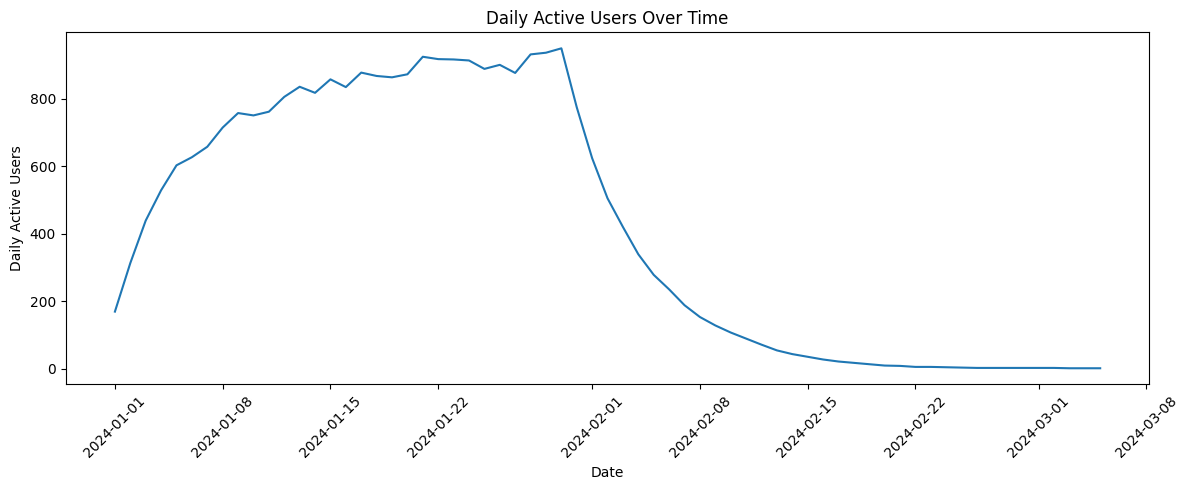

In [325]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    daily_activity["event_date"],
    daily_activity["DAU"]
)

plt.xlabel("Date")
plt.ylabel("Daily Active Users")
plt.title("Daily Active Users Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

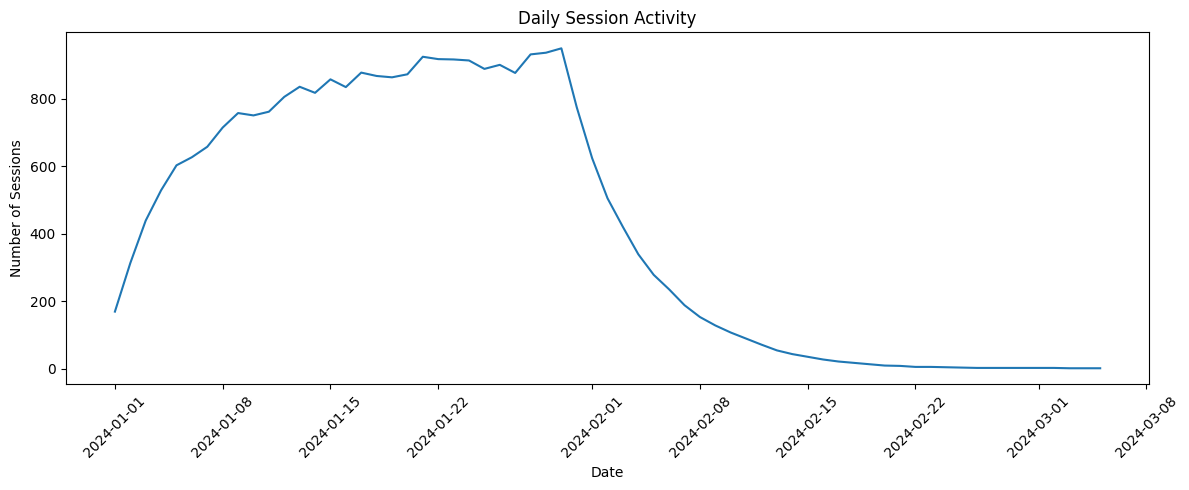

In [326]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_activity["event_date"],
    daily_activity["sessions"]
)

plt.xlabel("Date")
plt.ylabel("Number of Sessions")
plt.title("Daily Session Activity")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

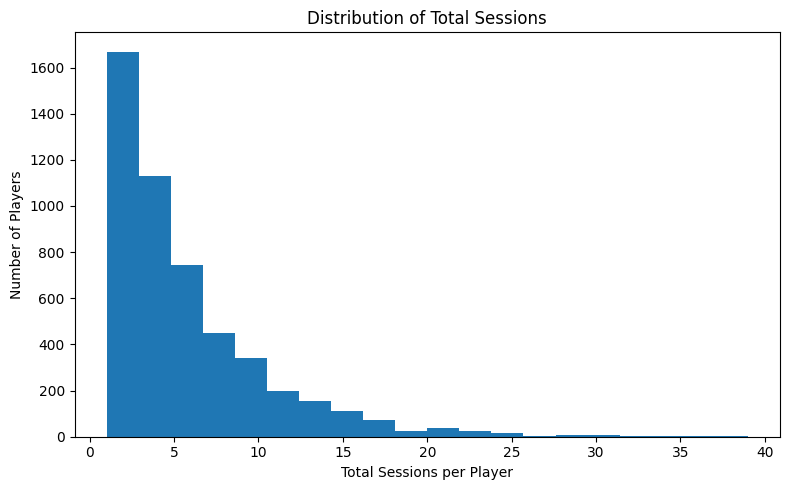

In [327]:
plt.figure(figsize=(8, 5))

plt.hist(
    player_stats["total_sessions"],
    bins=20
)

plt.xlabel("Total Sessions per Player")
plt.ylabel("Number of Players")
plt.title("Distribution of Total Sessions")

plt.tight_layout()
plt.show()

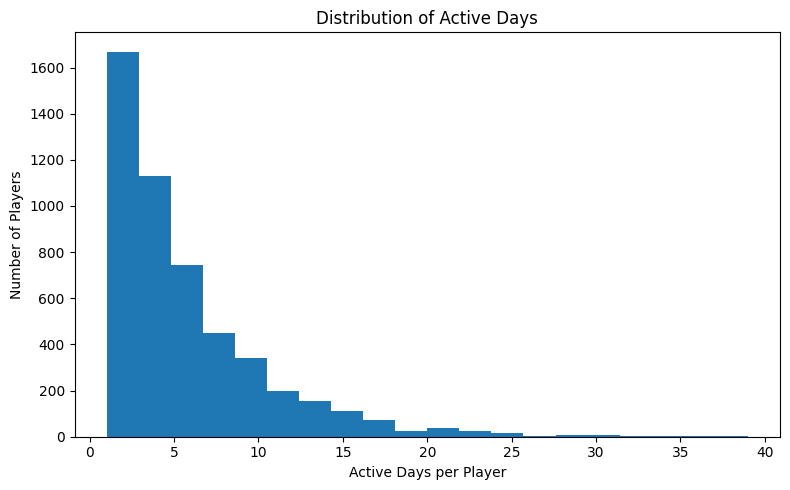

In [328]:
plt.figure(figsize=(8, 5))

plt.hist(
    player_stats["active_days"],
    bins=20
)

plt.xlabel("Active Days per Player")
plt.ylabel("Number of Players")
plt.title("Distribution of Active Days")

plt.tight_layout()
plt.show()

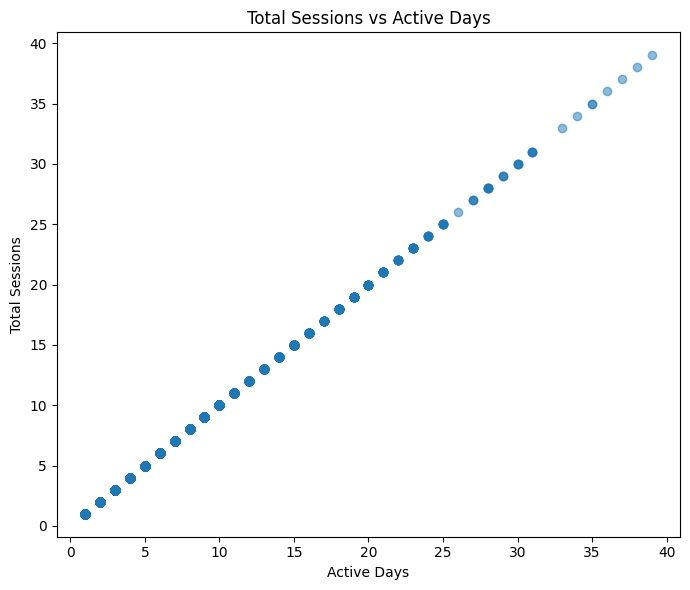

In [329]:
plt.figure(figsize=(7, 6))

plt.scatter(
    player_stats["active_days"],
    player_stats["total_sessions"],
    alpha=0.5
)

plt.xlabel("Active Days")
plt.ylabel("Total Sessions")
plt.title("Total Sessions vs Active Days")

plt.tight_layout()
plt.show()

In [330]:
high_activity_players = player_stats[
    player_stats["total_sessions"] > 14.5
].copy()

print(
    "Number of highly active players:",
    len(high_activity_players)
)

display(
    high_activity_players
    .sort_values(
        "total_sessions",
        ascending=False
    )
    .head(20)
)

Number of highly active players: 313


,user_id,total_sessions,active_days,sessions_per_active_day
990,991,39,39,1.0
3464,3465,38,38,1.0
3129,3130,37,37,1.0
4099,4100,36,36,1.0
4796,4797,35,35,1.0
743,744,35,35,1.0
2664,2665,34,34,1.0
3866,3867,33,33,1.0
2902,2903,31,31,1.0
1597,1598,31,31,1.0


In [331]:
def activity_level(sessions):
    if sessions <= 2:
        return "Low"
    elif sessions <= 7:
        return "Medium"
    else:
        return "High"

player_stats["activity_level"] = (
    player_stats["total_sessions"]
    .apply(activity_level)
)

print(
    player_stats["activity_level"]
    .value_counts()
)

activity_level
Medium    2120
Low       1669
High      1211
Name: count, dtype: int64


In [332]:
activity_distribution = (
    player_stats["activity_level"]
    .value_counts(normalize=True)
    .mul(100)
)

print(activity_distribution)

activity_level
Medium    42.40
Low       33.38
High      24.22
Name: proportion, dtype: float64


In [333]:
observation_end = master_events["event_date"].max()

print("Observation end date:", observation_end)

Observation end date: 2024-03-05 00:00:00


In [334]:
def calculate_retention(player_day, observation_end, day):

    # Players eligible to reach this lifecycle day
    eligible_players = player_day[
        player_day["install_date"] <=
        observation_end - pd.Timedelta(days=day)
    ]["user_id"].unique()

    # Players active exactly on the target lifecycle day
    retained_players = player_day[
        (player_day["days_since_install"] == day) &
        (player_day["user_id"].isin(eligible_players))
    ]["user_id"].nunique()

    eligible_count = len(eligible_players)

    retention_rate = (
        retained_players / eligible_count * 100
        if eligible_count > 0
        else 0
    )

    return eligible_count, retained_players, retention_rate

In [335]:
retention_days = [1, 3, 7, 14, 30]

retention_results = []

for day in retention_days:

    eligible, retained, rate = calculate_retention(
        player_day,
        observation_end,
        day
    )

    retention_results.append({
        "day": day,
        "eligible_players": eligible,
        "retained_players": retained,
        "retention_rate": rate
    })

retention_df = pd.DataFrame(retention_results)

display(retention_df)

,day,eligible_players,retained_players,retention_rate
0,1,5000,4094,81.88
1,3,5000,2696,53.92
2,7,5000,1211,24.22
3,14,5000,313,6.26
4,30,5000,12,0.24


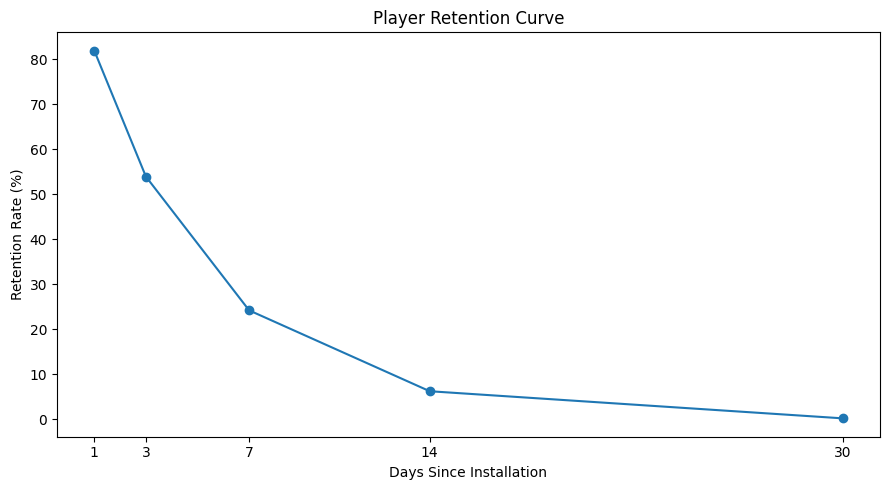

In [336]:
plt.figure(figsize=(9, 5))

plt.plot(
    retention_df["day"],
    retention_df["retention_rate"],
    marker="o"
)

plt.xlabel("Days Since Installation")
plt.ylabel("Retention Rate (%)")
plt.title("Player Retention Curve")

plt.xticks(retention_days)

plt.tight_layout()
plt.show()

In [337]:
retention_df["retention_drop"] = (
    retention_df["retention_rate"].shift(1)
    - retention_df["retention_rate"]
)

display(retention_df)

,day,eligible_players,retained_players,retention_rate,retention_drop
0,1,5000,4094,81.88,NaN
1,3,5000,2696,53.92,27.96
2,7,5000,1211,24.22,29.70
3,14,5000,313,6.26,17.96
4,30,5000,12,0.24,6.02


In [338]:
player_cohort = users_clean.copy()

player_cohort["cohort_week"] = (
    player_cohort["install_date"]
    .dt.to_period("W")
    .apply(lambda x: x.start_time)
)

display(player_cohort.head())


player_day_cohort = player_day.merge(
    player_cohort[
        ["user_id", "cohort_week"]
    ],
    on="user_id",
    how="left"
)

,user_id,install_date,cohort_week
0,1,2024-01-07,2024-01-01
1,2,2024-01-20,2024-01-15
2,3,2024-01-29,2024-01-29
3,4,2024-01-15,2024-01-15
4,5,2024-01-11,2024-01-08


In [339]:
player_day_cohort = player_day.merge(
    player_cohort[
        ["user_id", "cohort_week"]
    ],
    on="user_id",
    how="left"
)

In [340]:
cohort_results = []

for cohort, cohort_data in player_day_cohort.groupby("cohort_week"):

    cohort_players = cohort_data["user_id"].unique()

    cohort_install_dates = (
        player_cohort[
            player_cohort["user_id"].isin(cohort_players)
        ]
        [["user_id", "install_date"]]
        .drop_duplicates()
    )

    for day in retention_days:

        eligible_players = cohort_install_dates[
            cohort_install_dates["install_date"] <=
            observation_end - pd.Timedelta(days=day)
        ]["user_id"]

        retained_players = cohort_data[
            (cohort_data["days_since_install"] == day) &
            (cohort_data["user_id"].isin(eligible_players))
        ]["user_id"].nunique()

        eligible_count = len(eligible_players)

        retention_rate = (
            retained_players / eligible_count * 100
            if eligible_count > 0
            else np.nan
        )

        cohort_results.append({
            "cohort_week": cohort,
            "day": day,
            "eligible_players": eligible_count,
            "retained_players": retained_players,
            "retention_rate": retention_rate
        })

cohort_retention = pd.DataFrame(cohort_results)

display(cohort_retention)

,cohort_week,day,eligible_players,retained_players,retention_rate
0,2024-01-01,1,1177,960,81.563297
1,2024-01-01,3,1177,627,53.271028
2,2024-01-01,7,1177,271,23.024639
3,2024-01-01,14,1177,73,6.202209
4,2024-01-01,30,1177,3,0.254885
5,2024-01-08,1,1125,922,81.955556
6,2024-01-08,3,1125,620,55.111111
7,2024-01-08,7,1125,293,26.044444
8,2024-01-08,14,1125,72,6.400000
9,2024-01-08,30,1125,3,0.266667


In [341]:
cohort_matrix = cohort_retention.pivot(
    index="cohort_week",
    columns="day",
    values="retention_rate"
)

display(cohort_matrix)

day,1,3,7,14,30
cohort_week,,,,,
2024-01-01,81.563297,53.271028,23.024639,6.202209,0.254885
2024-01-08,81.955556,55.111111,26.044444,6.400000,0.266667
2024-01-15,81.018119,53.494392,24.503883,5.953408,0.172563
2024-01-22,83.528428,54.682274,24.498328,6.605351,0.334448
2024-01-29,79.883382,51.020408,20.408163,5.830904,0.000000


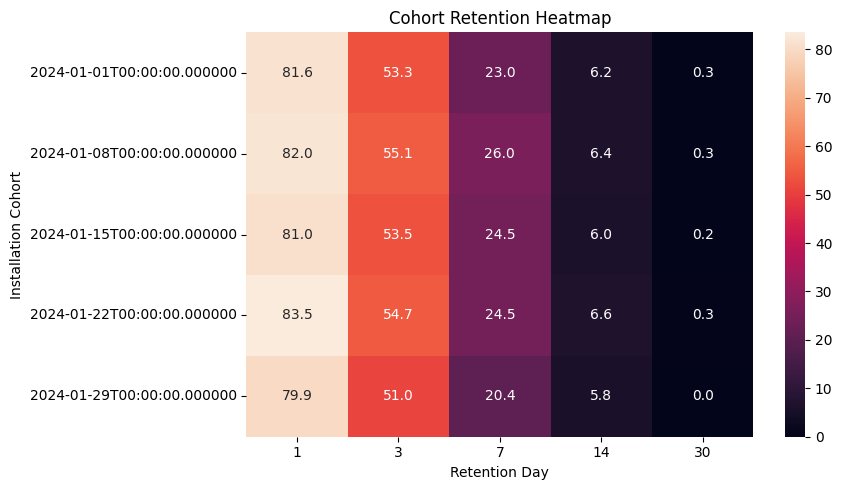

In [342]:
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.heatmap(
    cohort_matrix,
    annot=True,
    fmt=".1f"
)

plt.xlabel("Retention Day")
plt.ylabel("Installation Cohort")
plt.title("Cohort Retention Heatmap")

plt.tight_layout()
plt.show()

In [343]:
correlation_matrix = player_stats[
    [
        "total_sessions",
        "active_days",
        "sessions_per_active_day"
    ]
].corr()

print("CORRELATION MATRIX:")
display(correlation_matrix)

CORRELATION MATRIX:


,total_sessions,active_days,sessions_per_active_day
total_sessions,1.0,1.0,NaN
active_days,1.0,1.0,NaN
sessions_per_active_day,NaN,NaN,NaN


In [344]:
feature_variance = player_stats[
    [
        "total_sessions",
        "active_days",
        "sessions_per_active_day"
    ]
].var()

print("\nFEATURE VARIANCE:")
display(feature_variance)


FEATURE VARIANCE:


total_sessions             24.450343
active_days                24.450343
sessions_per_active_day     0.000000
dtype: float64

In [345]:
player_stats["active_days_log"] = np.log1p(
    player_stats["active_days"])

print("\nSKEWNESS COMPARISON:")

print(
    "Original active_days skewness:",
    player_stats["active_days"].skew()
)

print(
    "Log-transformed active_days skewness:",
    player_stats["active_days_log"].skew()
)


SKEWNESS COMPARISON:
Original active_days skewness: 1.937290213761388
Log-transformed active_days skewness: 0.31876990694261675


In [346]:
model_features = player_stats[
    [
        "user_id",
        "active_days",
        "active_days_log"
    ]
].copy()

print("\nPRELIMINARY MODELING FEATURES:")
display(model_features.head())


PRELIMINARY MODELING FEATURES:


,user_id,active_days,active_days_log
0,1,6,1.945910
1,2,4,1.609438
2,3,11,2.484907
3,4,2,1.098612
4,5,6,1.945910


In [347]:
model_features.isnull().sum()

user_id            0
active_days        0
active_days_log    0
dtype: int64

In [348]:
from scipy.stats import mannwhitneyu

# CREATE D7 RETENTION INDICATOR

d7_users = set(
    player_day.loc[
        player_day["days_since_install"] == 7,
        "user_id"
    ]
)

player_stats["d7_retained"] = (
    player_stats["user_id"]
    .isin(d7_users)
    .astype(int)
)

In [349]:
print("D7 RETENTION COUNTS:")
print(
    player_stats["d7_retained"]
    .value_counts()
)

D7 RETENTION COUNTS:
d7_retained
0    3789
1    1211
Name: count, dtype: int64


In [350]:
# CALCULATE EARLY ACTIVE DAYS (D0-D3)
early_activity = (
    player_day[
        player_day["days_since_install"].between(0, 3)
    ]
    .groupby("user_id")["days_since_install"]
    .nunique()
    .reset_index(name="early_active_days")
)

# 3. MERGE EARLY ACTIVITY INTO PLAYER TABLE

# Remove the old column if it exists from the previous attempt
if "early_active_days" in player_stats.columns:
    player_stats = player_stats.drop(
        columns=["early_active_days"]
    )

player_stats = player_stats.merge(
    early_activity,
    on="user_id",
    how="left"
)

print(
    "\nMissing early_active_days:",
    player_stats["early_active_days"].isnull().sum()
)


Missing early_active_days: 0


In [351]:
# DESCRIPTIVE STATISTICS BY D7 RETENTION

group_summary = (
    player_stats
    .groupby("d7_retained")["early_active_days"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )
)

print("\nEARLY ENGAGEMENT BY D7 RETENTION:")
display(group_summary)


EARLY ENGAGEMENT BY D7 RETENTION:


,count,mean,median,std,min,max
d7_retained,,,,,,
0,3789,2.712325,3.0,1.211355,1,4
1,1211,4.000000,4.0,0.000000,4,4


<Figure size 800x500 with 0 Axes>

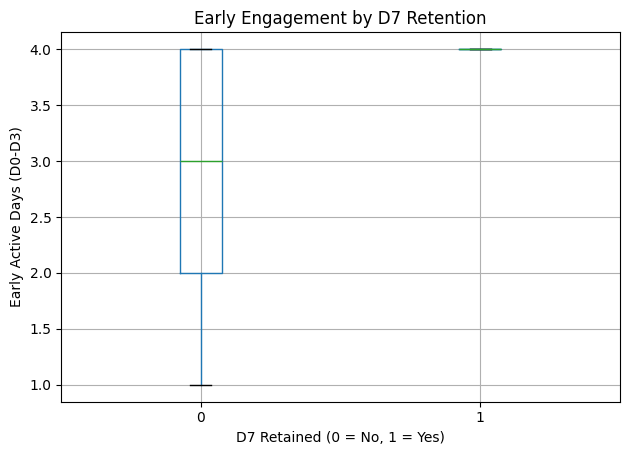

In [352]:
plt.figure(figsize=(8, 5))

player_stats.boxplot(
    column="early_active_days",
    by="d7_retained"
)

plt.xlabel("D7 Retained (0 = No, 1 = Yes)")
plt.ylabel("Early Active Days (D0-D3)")
plt.title("Early Engagement by D7 Retention")

plt.suptitle("")

plt.tight_layout()
plt.show()

In [353]:
group_not_retained = player_stats.loc[
    player_stats["d7_retained"] == 0,
    "early_active_days"
]

group_retained = player_stats.loc[
    player_stats["d7_retained"] == 1,
    "early_active_days"
]

# MANN-WHITNEY U TEST

u_statistic, p_value = mannwhitneyu(
    group_not_retained,
    group_retained,
    alternative="two-sided"
)

print("\nMANN-WHITNEY U TEST:")
print("U statistic:", u_statistic)
print("p-value:", p_value)


MANN-WHITNEY U TEST:
U statistic: 899167.5
p-value: 4.2184342538290737e-268


In [354]:
# HYPOTHESIS DECISION

alpha = 0.05

print("\nHYPOTHESIS DECISION:")

if p_value < alpha:

    print(
        "Reject the null hypothesis."
    )

else:

    print(
        "Fail to reject the null hypothesis."
    )


HYPOTHESIS DECISION:
Reject the null hypothesis.


In [355]:
# EFFECT SIZE

n1 = len(group_not_retained)
n2 = len(group_retained)

N = n1 + n2

mean_U = n1 * n2 / 2

std_U = np.sqrt(
    n1 * n2 * (N + 1) / 12
)

z = (
    u_statistic - mean_U
) / std_U

effect_size_r = z / np.sqrt(N)

print("\nEFFECT SIZE:")
print("r:", effect_size_r)
print("|r|:", abs(effect_size_r))


EFFECT SIZE:
r: -0.4511691975362244
|r|: 0.4511691975362244


In [356]:
print("\nMEDIAN COMPARISON:")

print(
    "Not D7 retained:",
    group_not_retained.median()
)

print(
    "D7 retained:",
    group_retained.median()
)


MEDIAN COMPARISON:
Not D7 retained: 3.0
D7 retained: 4.0


In [357]:
print("\nMEAN COMPARISON:")

print(
    "Not D7 retained:",
    group_not_retained.mean()
)

print(
    "D7 retained:",
    group_retained.mean()
)


MEAN COMPARISON:
Not D7 retained: 2.7123251517550804
D7 retained: 4.0


In [358]:
# HYPOTHESIS TEST 2:
# INSTALLATION COHORT VS D7 RETENTION

if "cohort_week" in player_stats.columns:
    player_stats = player_stats.drop(columns=["cohort_week"])


# Merge cohort information from player_cohort
player_stats = player_stats.merge(
    player_cohort[["user_id", "cohort_week"]],
    on="user_id",
    how="left"
)


display(
    player_stats[
        ["user_id", "cohort_week", "d7_retained"]
    ].head()
)

,user_id,cohort_week,d7_retained
0,1,2024-01-01,0
1,2,2024-01-15,0
2,3,2024-01-29,1
3,4,2024-01-15,0
4,5,2024-01-08,0


In [359]:
print("MISSING VALUES:")

print(
    "cohort_week:",
    player_stats["cohort_week"].isnull().sum()
)

print(
    "d7_retained:",
    player_stats["d7_retained"].isnull().sum()
)

MISSING VALUES:
cohort_week: 0
d7_retained: 0


In [360]:
cohort_table = pd.crosstab(
    player_stats["cohort_week"],
    player_stats["d7_retained"]
)

cohort_table.columns = [
    "Not_D7_Retained",
    "D7_Retained"
]

print("COHORT × D7 RETENTION TABLE:")
display(cohort_table)

COHORT × D7 RETENTION TABLE:


,Not_D7_Retained,D7_Retained
cohort_week,,
2024-01-01,906,271
2024-01-08,832,293
2024-01-15,875,284
2024-01-22,903,293
2024-01-29,273,70


In [361]:
cohort_retention_pct = (
    cohort_table["D7_Retained"]
    /
    cohort_table.sum(axis=1)
    * 100
)

print("D7 RETENTION BY COHORT (%):")

display(
    cohort_retention_pct.round(2)
)

D7 RETENTION BY COHORT (%):


cohort_week
2024-01-01    23.02
2024-01-08    26.04
2024-01-15    24.50
2024-01-22    24.50
2024-01-29    20.41
dtype: float64

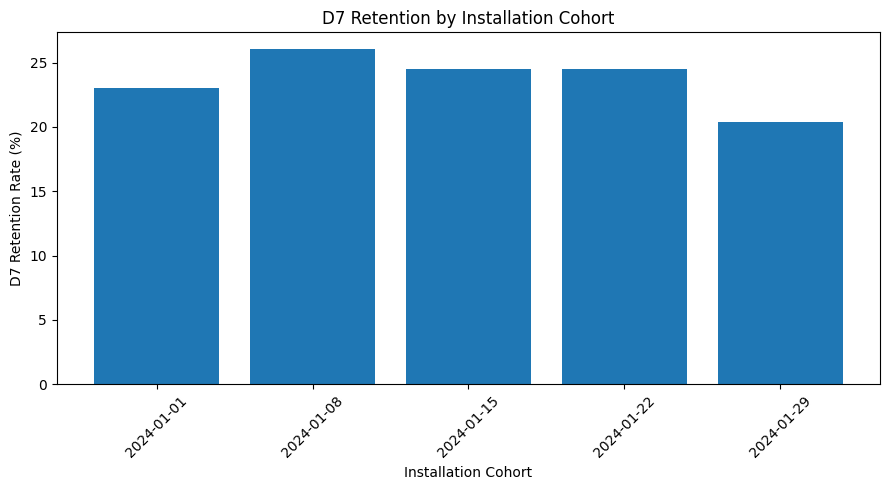

In [362]:
plt.figure(figsize=(9, 5))

plt.bar(
    cohort_retention_pct.index.astype(str),
    cohort_retention_pct.values
)

plt.xlabel("Installation Cohort")
plt.ylabel("D7 Retention Rate (%)")
plt.title("D7 Retention by Installation Cohort")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [363]:
from scipy.stats import chi2_contingency

chi2_stat, p_value, degrees_freedom, expected = (
    chi2_contingency(cohort_table)
)

print("CHI-SQUARE TEST:")
print("Chi-square statistic:", chi2_stat)
print("Degrees of freedom:", degrees_freedom)
print("p-value:", p_value)

CHI-SQUARE TEST:
Chi-square statistic: 5.773345821277294
Degrees of freedom: 4
p-value: 0.21672643003267067


In [364]:
expected_table = pd.DataFrame(
    expected,
    index=cohort_table.index,
    columns=cohort_table.columns
)

print("EXPECTED FREQUENCIES:")

display(
    expected_table.round(2)
)

EXPECTED FREQUENCIES:


,Not_D7_Retained,D7_Retained
cohort_week,,
2024-01-01,891.93,285.07
2024-01-08,852.52,272.48
2024-01-15,878.29,280.71
2024-01-22,906.33,289.67
2024-01-29,259.93,83.07


In [365]:
alpha = 0.05

print("HYPOTHESIS DECISION:")

if p_value < alpha:

    print(
        "Reject the null hypothesis."
    )

else:

    print(
        "Fail to reject the null hypothesis."
    )

HYPOTHESIS DECISION:
Fail to reject the null hypothesis.


In [366]:
N = cohort_table.to_numpy().sum()

rows, columns = cohort_table.shape

k = min(rows, columns)

cramers_v = np.sqrt(
    chi2_stat / (N * (k - 1))
)

print("CRAMER'S V:", cramers_v)

CRAMER'S V: 0.03398042325009297


In [367]:
# HYPOTHESIS TEST 3:
# EARLY ENGAGEMENT (D0-D7) VS D14 RETENTION
# CREATE D14 RETENTION INDICATOR

d14_users = set(
    player_day.loc[
        player_day["days_since_install"] == 14,
        "user_id"
    ]
)

player_stats["d14_retained"] = (
    player_stats["user_id"]
    .isin(d14_users)
    .astype(int)
)

print("D14 RETENTION COUNTS:")

print(
    player_stats["d14_retained"]
    .value_counts()
)

D14 RETENTION COUNTS:
d14_retained
0    4687
1     313
Name: count, dtype: int64


In [368]:
# CALCULATE EARLY ACTIVE DAYS (D0-D7)
early_activity_d14 = (
    player_day[
        player_day["days_since_install"].between(0, 6)
    ]
    .groupby("user_id")["days_since_install"]
    .nunique()
    .reset_index(name="early_active_days_d0_d6")
)

display(early_activity_d14.head())

,user_id,early_active_days_d0_d6
0,1,6
1,2,4
2,3,7
3,4,2
4,5,6


In [369]:
# MERGE EARLY ACTIVITY

if "early_active_days_d0_d7" in player_stats.columns:
    player_stats = player_stats.drop(
        columns=["early_active_days_d0_d7"]
    )

player_stats = player_stats.merge(
    early_activity_d14,
    on="user_id",
    how="left"
)

print(
    "Missing early_active_days_d0_d7:",
    player_stats["early_active_days_d0_d6"].isnull().sum()
)

Missing early_active_days_d0_d7: 0


In [370]:
#  DESCRIPTIVE STATISTICS

group_summary_d14 = (
    player_stats
    .groupby("d14_retained")["early_active_days_d0_d6"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "std",
            "min",
            "max"
        ]
    )
)

print("EARLY ENGAGEMENT BY D14 RETENTION:")

display(group_summary_d14)

EARLY ENGAGEMENT BY D14 RETENTION:


,count,mean,median,std,min,max
d14_retained,,,,,,
0,4687,3.922552,4.0,2.257008,1,7
1,313,7.000000,7.0,0.000000,7,7


<Figure size 800x500 with 0 Axes>

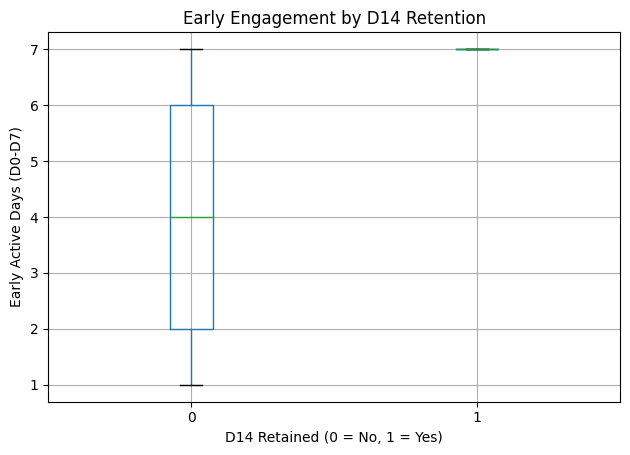

In [371]:
plt.figure(figsize=(8, 5))

player_stats.boxplot(
    column="early_active_days_d0_d6",
    by="d14_retained"
)

plt.xlabel("D14 Retained (0 = No, 1 = Yes)")
plt.ylabel("Early Active Days (D0-D7)")
plt.title("Early Engagement by D14 Retention")

plt.suptitle("")

plt.tight_layout()
plt.show()

In [372]:
group_not_retained_d14 = player_stats.loc[
    player_stats["d14_retained"] == 0,
    "early_active_days_d0_d6"
]

group_retained_d14 = player_stats.loc[
    player_stats["d14_retained"] == 1,
    "early_active_days_d0_d6"
]

In [373]:
# -WHITNEY U TEST

u_statistic_d14, p_value_d14 = mannwhitneyu(
    group_not_retained_d14,
    group_retained_d14,
    alternative="two-sided"
)

print("MANN-WHITNEY U TEST:")

print(
    "U statistic:",
    u_statistic_d14
)

print(
    "p-value:",
    p_value_d14
)

MANN-WHITNEY U TEST:
U statistic: 179192.5
p-value: 1.195803874920658e-115


In [374]:
# HYPOTHESIS DECISION
alpha = 0.05

print("HYPOTHESIS DECISION:")

if p_value_d14 < alpha:

    print(
        "Reject the null hypothesis."
    )

else:

    print(
        "Fail to reject the null hypothesis."
    )

HYPOTHESIS DECISION:
Reject the null hypothesis.


In [375]:
# EFFECT SIZE

n1_d14 = len(group_not_retained_d14)
n2_d14 = len(group_retained_d14)

N_d14 = n1_d14 + n2_d14

mean_U_d14 = (
    n1_d14 * n2_d14 / 2
)

std_U_d14 = np.sqrt(
    n1_d14
    * n2_d14
    * (N_d14 + 1)
    / 12
)

z_d14 = (
    u_statistic_d14 - mean_U_d14
) / std_U_d14

effect_size_d14 = (
    z_d14 / np.sqrt(N_d14)
)

print("EFFECT SIZE:")

print(
    "r:",
    effect_size_d14
)

print(
    "|r|:",
    abs(effect_size_d14)
)

EFFECT SIZE:
r: -0.3170446629533355
|r|: 0.3170446629533355


In [376]:
# MEDIAN COMPARISON

print("MEDIAN COMPARISON:")

print(
    "Not D14 retained:",
    group_not_retained_d14.median()
)

print(
    "D14 retained:",
    group_retained_d14.median()
)

MEDIAN COMPARISON:
Not D14 retained: 4.0
D14 retained: 7.0


In [377]:
#  MEAN COMPARISON
print("MEAN COMPARISON:")

print(
    "Not D14 retained:",
    group_not_retained_d14.mean()
)

print(
    "D14 retained:",
    group_retained_d14.mean()
)

MEAN COMPARISON:
Not D14 retained: 3.9225517388521443
D14 retained: 7.0


In [378]:

# FEATURE SELECTION, TRANSFORMATION & SCALING


from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. CREATE / CHECK PLAYER-LEVEL DATA
# ============================================================

# player_stats must contain one row per player.
# If it already exists from the previous phase, we keep it.
# Otherwise, create it from player_day.

if "player_stats" not in globals():

    print("player_stats not found.")
    print("Creating player-level statistics from player_day...")

    player_stats = (
        player_day
        .groupby("user_id")
        .agg(
            total_sessions=("user_id", "count"),
            active_days=("event_date", "nunique")
        )
        .reset_index()
    )

else:

    print("player_stats already exists.")
    print("Using existing player_stats.")


# ============================================================
# 2. CHECK REQUIRED COLUMNS
# ============================================================

required_features = [
    "user_id",
    "total_sessions",
    "active_days"
]


missing_columns = [
    col
    for col in required_features
    if col not in player_stats.columns
]


if missing_columns:

    raise ValueError(
        f"Missing required columns in player_stats: "
        f"{missing_columns}"
    )


# ============================================================
# 3. CHECK NUMBER OF PLAYERS
# ============================================================

print("\nPLAYER-LEVEL DATA:")

print(
    "Number of players:",
    player_stats["user_id"].nunique()
)

print(
    "Number of rows:",
    len(player_stats)
)


# ============================================================
# 4. SELECT CLUSTERING FEATURES
# ============================================================

clustering_features = [
    "total_sessions",
    "active_days"
]


print("\nCLUSTERING FEATURES:")

print(clustering_features)


# ============================================================
# 5. DESCRIPTIVE STATISTICS
# ============================================================

print("\nDESCRIPTIVE STATISTICS:")

display(
    player_stats[
        clustering_features
    ].describe()
)


# ============================================================
# 6. CHECK MISSING VALUES
# ============================================================

print("\nMISSING VALUES:")

display(
    player_stats[
        clustering_features
    ].isnull().sum()
)


# ============================================================
# 7. CHECK VARIANCE
# ============================================================

print("\nFEATURE VARIANCE:")

display(
    player_stats[
        clustering_features
    ].var()
)


# ============================================================
# 8. CREATE CLUSTERING DATA
# ============================================================

clustering_data = (
    player_stats[
        clustering_features
    ]
    .copy()
)


# ============================================================
# 9. LOG TRANSFORMATION
# ============================================================

clustering_data["total_sessions_log"] = np.log1p(
    clustering_data["total_sessions"]
)

clustering_data["active_days_log"] = np.log1p(
    clustering_data["active_days"]
)


# ============================================================
# 10. CHECK SKEWNESS
# ============================================================

print("\nSKEWNESS BEFORE LOG TRANSFORMATION:")

display(
    clustering_data[
        [
            "total_sessions",
            "active_days"
        ]
    ].skew()
)


print("\nSKEWNESS AFTER LOG TRANSFORMATION:")

display(
    clustering_data[
        [
            "total_sessions_log",
            "active_days_log"
        ]
    ].skew()
)


# ============================================================
# 11. CREATE FINAL CLUSTERING MATRIX
# ============================================================

X_cluster = clustering_data[
    [
        "total_sessions_log",
        "active_days_log"
    ]
].copy()


print("\nFINAL CLUSTERING DATA:")

display(
    X_cluster.head()
)

print(
    "\nShape:",
    X_cluster.shape
)


# ============================================================
# 12. STANDARDIZE FEATURES
# ============================================================

scaler = StandardScaler()

X_cluster_scaled = scaler.fit_transform(
    X_cluster
)


# ============================================================
# 13. CONVERT TO DATAFRAME FOR VALIDATION
# ============================================================

X_cluster_scaled_df = pd.DataFrame(
    X_cluster_scaled,
    columns=[
        "total_sessions_scaled",
        "active_days_scaled"
    ]
)


# ============================================================
# 14. VALIDATE STANDARDIZATION
# ============================================================

print("\nMEAN AFTER SCALING:")

display(
    X_cluster_scaled_df.mean()
)


print("\nSTANDARD DEVIATION AFTER SCALING:")

display(
    X_cluster_scaled_df.std()
)


# ============================================================
# 15. FINAL VALIDATION
# ============================================================

print("\nFINAL CLUSTERING MATRIX:")

display(
    X_cluster_scaled_df.head()
)

print(
    "\nRows:",
    X_cluster_scaled_df.shape[0]
)

print(
    "Features:",
    X_cluster_scaled_df.shape[1]
)

print("\nMissing values:")

display(
    X_cluster_scaled_df.isnull().sum()
)


print("\nPHASE 4 PART 1 COMPLETE.")

player_stats already exists.
Using existing player_stats.

PLAYER-LEVEL DATA:
Number of players: 5000
Number of rows: 5000

CLUSTERING FEATURES:
['total_sessions', 'active_days']

DESCRIPTIVE STATISTICS:


,total_sessions,active_days
count,5000.000000,5000.000000
mean,5.458200,5.458200
std,4.944729,4.944729
min,1.000000,1.000000
25%,2.000000,2.000000
50%,4.000000,4.000000
75%,7.000000,7.000000
max,39.000000,39.000000



MISSING VALUES:


total_sessions    0
active_days       0
dtype: int64


FEATURE VARIANCE:


...


FINAL CLUSTERING MATRIX:


,total_sessions_scaled,active_days_scaled
0,0.471514,0.471514
1,-0.025479,-0.025479
2,1.267649,1.267649
3,-0.780004,-0.780004
4,0.471514,0.471514



Rows: 5000
Features: 2

Missing values:


total_sessions_scaled    0
active_days_scaled       0
dtype: int64


PHASE 4 PART 1 COMPLETE.


K VALUES:
[2, 3, 4, 5, 6, 7, 8]

INERTIA / WCSS VALUES:
K = 2: 2962.00
K = 3: 1344.81
K = 4: 789.16
K = 5: 436.05
K = 6: 271.90
K = 7: 183.12
K = 8: 123.76


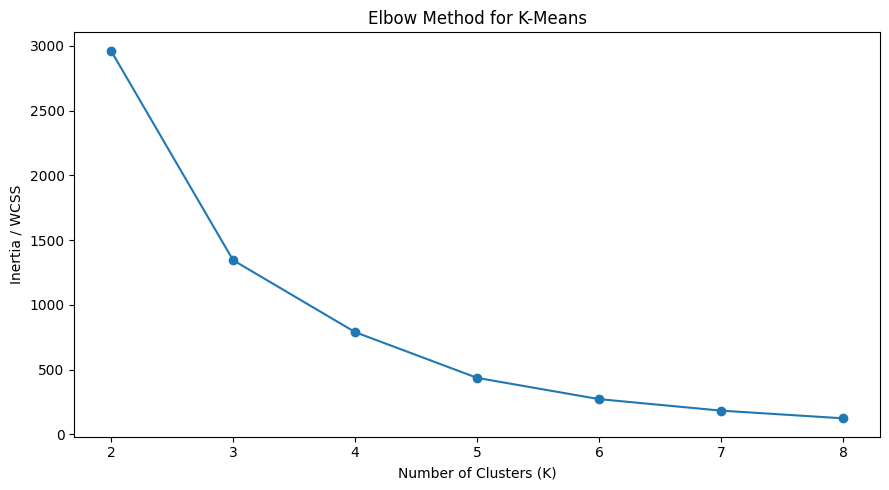


CLUSTER SIZE DISTRIBUTIONS:

K = 2


,Players,Percentage
0,2797,55.94
1,2203,44.06



K = 3


,Players,Percentage
0,1669,33.38
1,2120,42.40
2,1211,24.22



K = 4


...

,Players,Percentage
0,763,15.26
1,828,16.56
2,992,19.84
3,906,18.12
4,383,7.66
5,1128,22.56



K = 7


,Players,Percentage
0,635,12.70
1,625,12.50
2,906,18.12
3,902,18.04
4,383,7.66
5,763,15.26
6,786,15.72



K = 8


,Players,Percentage
0,763,15.26
1,786,15.72
2,365,7.30
3,906,18.12
4,902,18.04
5,635,12.70
6,540,10.80
7,103,2.06


In [379]:
# ELBOW METHOD FOR K-MEANS
from sklearn.cluster import KMeans

k_values = range(2, 9)

inertia_values = {}
cluster_results = {}


# Fit K-Means for each K
for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_cluster_scaled
    )

    inertia_values[k] = kmeans.inertia_
    cluster_results[k] = labels


print("K VALUES:")
print(list(k_values))


print("\nINERTIA / WCSS VALUES:")

for k in k_values:

    print(
        f"K = {k}: "
        f"{inertia_values[k]:.2f}"
    )


# Elbow plot
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    list(inertia_values.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method for K-Means")

plt.xticks(list(k_values))

plt.tight_layout()
plt.show()


# Cluster sizes
def cluster_size_summary(k):

    labels = cluster_results[k]

    counts = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    percentages = (
        counts / len(labels) * 100
    )

    return pd.DataFrame({
        "Players": counts,
        "Percentage": percentages.round(2)
    })


print("\nCLUSTER SIZE DISTRIBUTIONS:")

for k in k_values:

    print(f"\nK = {k}")

    display(
        cluster_size_summary(k)
    )

SILHOUETTE SCORES:
K = 2: 0.6067
K = 3: 0.6082
K = 4: 0.6094
K = 5: 0.6710
K = 6: 0.7289
K = 7: 0.7750
K = 8: 0.7763

HIGHEST SILHOUETTE SCORE:
K = 8
Silhouette Score = 0.7763


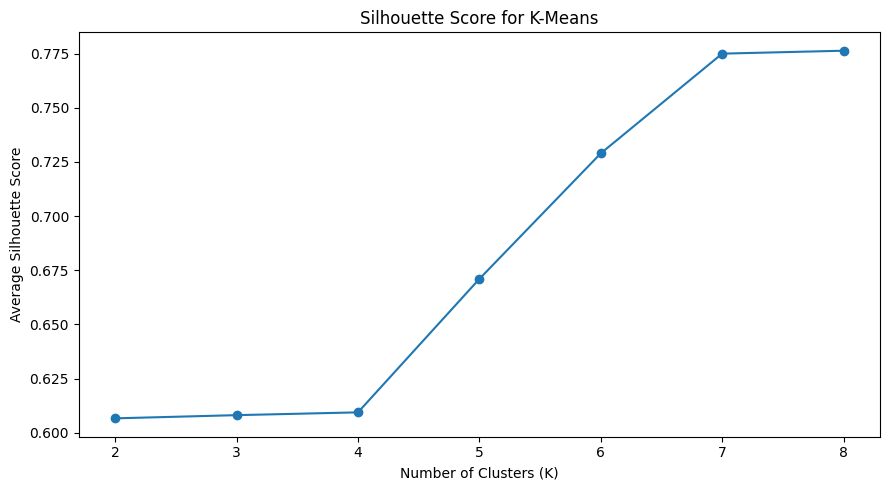


K SELECTION COMPARISON:


,K,Inertia_WCSS,Silhouette_Score
0,2,2962.0029,0.6067
1,3,1344.8050,0.6082
2,4,789.1596,0.6094
3,5,436.0502,0.6710
4,6,271.8952,0.7289
5,7,183.1179,0.7750
6,8,123.7589,0.7763



FINAL K SELECTED:
K = 7
Silhouette Score for K=7 = 0.775
Silhouette Score for K=8 = 0.7763

CLUSTER SIZE DISTRIBUTION FOR K=7:


,Players,Percentage
0,635,12.70
1,625,12.50
2,906,18.12
3,902,18.04
4,383,7.66
5,763,15.26
6,786,15.72


In [380]:
# SILHOUETTE ANALYSIS & K SELECTION

from sklearn.metrics import silhouette_score


silhouette_values = {}


# Calculate silhouette scores
for k in k_values:

    labels = cluster_results[k]

    score = silhouette_score(
        X_cluster_scaled,
        labels
    )

    silhouette_values[k] = score


print("SILHOUETTE SCORES:")

for k, score in silhouette_values.items():

    print(
        f"K = {k}: {score:.4f}"
    )


# Highest silhouette score
best_k_silhouette = max(
    silhouette_values,
    key=silhouette_values.get
)

best_silhouette_score = silhouette_values[
    best_k_silhouette
]


print("\nHIGHEST SILHOUETTE SCORE:")

print(
    "K =",
    best_k_silhouette
)

print(
    "Silhouette Score =",
    round(best_silhouette_score, 4)
)


# Silhouette plot
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_values),
    list(silhouette_values.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Average Silhouette Score")
plt.title("Silhouette Score for K-Means")

plt.xticks(list(k_values))

plt.tight_layout()
plt.show()


# Compare inertia and silhouette
comparison_df = pd.DataFrame({
    "K": list(k_values),
    "Inertia_WCSS": [
        inertia_values[k]
        for k in k_values
    ],
    "Silhouette_Score": [
        silhouette_values[k]
        for k in k_values
    ]
})


print("\nK SELECTION COMPARISON:")

display(
    comparison_df.round(4)
)


# Final K selection
k_best = 7

print("\nFINAL K SELECTED:")

print(
    "K =",
    k_best
)

print(
    "Silhouette Score for K=7 =",
    round(silhouette_values[7], 4)
)

print(
    "Silhouette Score for K=8 =",
    round(silhouette_values[8], 4)
)


# Cluster sizes for selected K
labels_best = cluster_results[k_best]

cluster_counts = (
    pd.Series(labels_best)
    .value_counts()
    .sort_index()
)

cluster_percentages = (
    cluster_counts
    / len(labels_best)
    * 100
)

cluster_size_table = pd.DataFrame({
    "Players": cluster_counts,
    "Percentage": cluster_percentages.round(2)
})


print("\nCLUSTER SIZE DISTRIBUTION FOR K=7:")

display(
    cluster_size_table
)

FINAL K-MEANS MODEL
Number of clusters: 7
Number of players: 5000

PLAYER CLUSTER ASSIGNMENTS:


,user_id,total_sessions,active_days,cluster
0,1,6,6,6
1,2,4,4,3
2,3,11,11,1
3,4,2,2,5
4,5,6,6,6
5,6,5,5,3
6,7,2,2,5
7,8,1,1,2
8,9,6,6,6
9,10,7,7,6



CLUSTER BEHAVIORAL PROFILE:


,players,avg_sessions,median_sessions,avg_active_days,median_active_days,percentage
cluster,,,,,,
0,635,3.00,3.0,3.00,3.0,12.70
1,625,10.55,10.0,10.55,10.0,12.50
2,906,1.00,1.0,1.00,1.0,18.12
3,902,4.45,4.0,4.45,4.0,18.04
4,383,18.21,17.0,18.21,17.0,7.66
5,763,2.00,2.0,2.00,2.0,15.26
6,786,6.83,7.0,6.83,7.0,15.72



CLUSTERS ORDERED BY AVERAGE SESSION ACTIVITY:


,players,avg_sessions,median_sessions,avg_active_days,median_active_days,percentage
cluster,,,,,,
2,906,1.00,1.0,1.00,1.0,18.12
5,763,2.00,2.0,2.00,2.0,15.26
0,635,3.00,3.0,3.00,3.0,12.70
3,902,4.45,4.0,4.45,4.0,18.04
6,786,6.83,7.0,6.83,7.0,15.72
1,625,10.55,10.0,10.55,10.0,12.50
4,383,18.21,17.0,18.21,17.0,7.66



ACTIVITY SEGMENT DISTRIBUTION:


,cluster,activity_segment
12,0,Low-Moderate Activity
2,1,High Activity
7,2,Very Low Activity
1,3,Moderate Activity
35,4,Very High Activity
3,5,Low Activity
0,6,Moderately High Activity



FINAL ACTIVITY SEGMENT SUMMARY:


,players,avg_sessions,median_sessions,avg_active_days,median_active_days,percentage
activity_segment,,,,,,
Very Low Activity,906,1.00,1.0,1.00,1.0,18.12
Low Activity,763,2.00,2.0,2.00,2.0,15.26
Low-Moderate Activity,635,3.00,3.0,3.00,3.0,12.70
Moderate Activity,902,4.45,4.0,4.45,4.0,18.04
Moderately High Activity,786,6.83,7.0,6.83,7.0,15.72
High Activity,625,10.55,10.0,10.55,10.0,12.50
Very High Activity,383,18.21,17.0,18.21,17.0,7.66


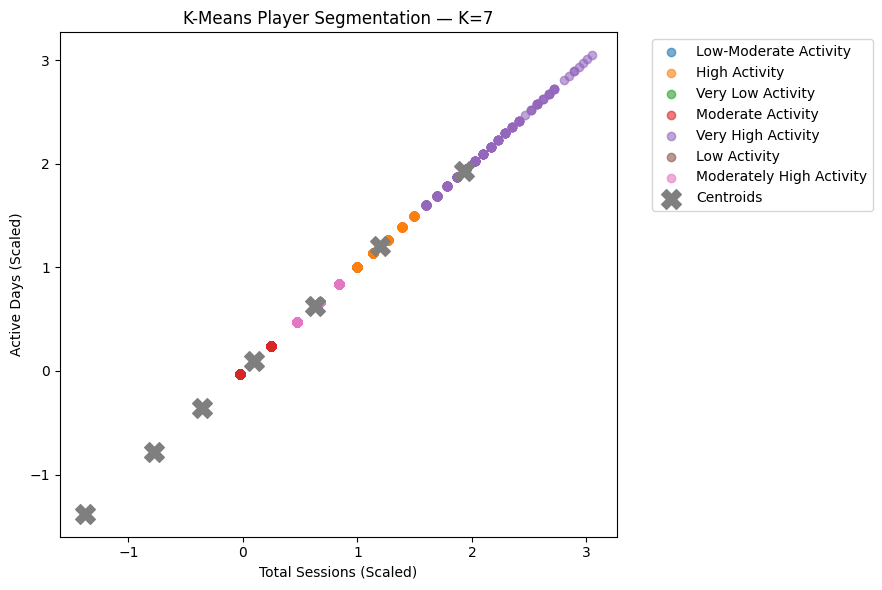


PHASE 4 PART 4 COMPLETE.


In [381]:
# FINAL K-MEANS MODEL & PLAYER SEGMENTATION


from sklearn.cluster import KMeans


k_best = 7


# Final K-Means model
final_kmeans = KMeans(
    n_clusters=k_best,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(
    X_cluster_scaled
)


print("FINAL K-MEANS MODEL")
print("Number of clusters:", k_best)
print("Number of players:", len(final_labels))


# Add cluster labels
if "cluster" in player_stats.columns:
    player_stats = player_stats.drop(columns=["cluster"])

player_stats["cluster"] = final_labels


print("\nPLAYER CLUSTER ASSIGNMENTS:")

display(
    player_stats[
        [
            "user_id",
            "total_sessions",
            "active_days",
            "cluster"
        ]
    ].head(10)
)


# Cluster behavioral profile
cluster_profile = (
    player_stats
    .groupby("cluster")
    .agg(
        players=("user_id", "count"),
        avg_sessions=("total_sessions", "mean"),
        median_sessions=("total_sessions", "median"),
        avg_active_days=("active_days", "mean"),
        median_active_days=("active_days", "median")
    )
)

cluster_profile["percentage"] = (
    cluster_profile["players"]
    / len(player_stats)
    * 100
)


print("\nCLUSTER BEHAVIORAL PROFILE:")

display(
    cluster_profile.round(2)
)


# Order clusters by activity
cluster_profile_sorted = (
    cluster_profile
    .sort_values("avg_sessions")
)


print("\nCLUSTERS ORDERED BY AVERAGE SESSION ACTIVITY:")

display(
    cluster_profile_sorted.round(2)
)


# Assign meaningful activity labels
ordered_clusters = cluster_profile_sorted.index.tolist()

activity_labels = [
    "Very Low Activity",
    "Low Activity",
    "Low-Moderate Activity",
    "Moderate Activity",
    "Moderately High Activity",
    "High Activity",
    "Very High Activity"
]

cluster_to_activity = {
    cluster: activity_labels[i]
    for i, cluster in enumerate(ordered_clusters)
}


if "activity_segment" in player_stats.columns:
    player_stats = player_stats.drop(
        columns=["activity_segment"]
    )

player_stats["activity_segment"] = (
    player_stats["cluster"]
    .map(cluster_to_activity)
)


print("\nACTIVITY SEGMENT DISTRIBUTION:")

display(
    player_stats[
        ["cluster", "activity_segment"]
    ]
    .drop_duplicates()
    .sort_values("cluster")
)


# Final segment summary
segment_summary = (
    player_stats
    .groupby("activity_segment")
    .agg(
        players=("user_id", "count"),
        avg_sessions=("total_sessions", "mean"),
        median_sessions=("total_sessions", "median"),
        avg_active_days=("active_days", "mean"),
        median_active_days=("active_days", "median")
    )
)

segment_summary["percentage"] = (
    segment_summary["players"]
    / len(player_stats)
    * 100
)

segment_summary = (
    segment_summary
    .sort_values("avg_sessions")
)


print("\nFINAL ACTIVITY SEGMENT SUMMARY:")

display(
    segment_summary.round(2)
)


# K-Means visualization
plt.figure(figsize=(9, 6))

for cluster in sorted(
    player_stats["cluster"].unique()
):

    mask = (
        player_stats["cluster"] == cluster
    )

    plt.scatter(
        X_cluster_scaled[mask, 0],
        X_cluster_scaled[mask, 1],
        label=cluster_to_activity[cluster],
        alpha=0.6
    )


# Plot centroids
centroids = final_kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)


plt.xlabel("Total Sessions (Scaled)")
plt.ylabel("Active Days (Scaled)")

plt.title(
    f"K-Means Player Segmentation — K={k_best}"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


print("\nPHASE 4 PART 4 COMPLETE.")

RETENTION COUNTS:

D1:
d1_retained
1    4094
0     906
Name: count, dtype: int64

D7:
d7_retained
0    3789
1    1211
Name: count, dtype: int64

D14:
d14_retained
0    4687
1     313
Name: count, dtype: int64

RETENTION BY ACTIVITY SEGMENT:


,players,d1_retained,d7_retained,d14_retained,d1_retention_pct,d7_retention_pct,d14_retention_pct
activity_segment,,,,,,,
Very Low Activity,906,0,0,0,0.0,0.00,0.00
Low Activity,763,763,0,0,100.0,0.00,0.00
Low-Moderate Activity,635,635,0,0,100.0,0.00,0.00
Moderate Activity,902,902,0,0,100.0,0.00,0.00
Moderately High Activity,786,786,203,0,100.0,25.83,0.00
High Activity,625,625,625,0,100.0,100.00,0.00
Very High Activity,383,383,383,313,100.0,100.00,81.72



FINAL SEGMENT RETENTION TABLE:


,Players,D1 Retention (%),D7 Retention (%),D14 Retention (%)
activity_segment,,,,
Very Low Activity,906,0.0,0.00,0.00
Low Activity,763,100.0,0.00,0.00
Low-Moderate Activity,635,100.0,0.00,0.00
Moderate Activity,902,100.0,0.00,0.00
Moderately High Activity,786,100.0,25.83,0.00
High Activity,625,100.0,100.00,0.00
Very High Activity,383,100.0,100.00,81.72


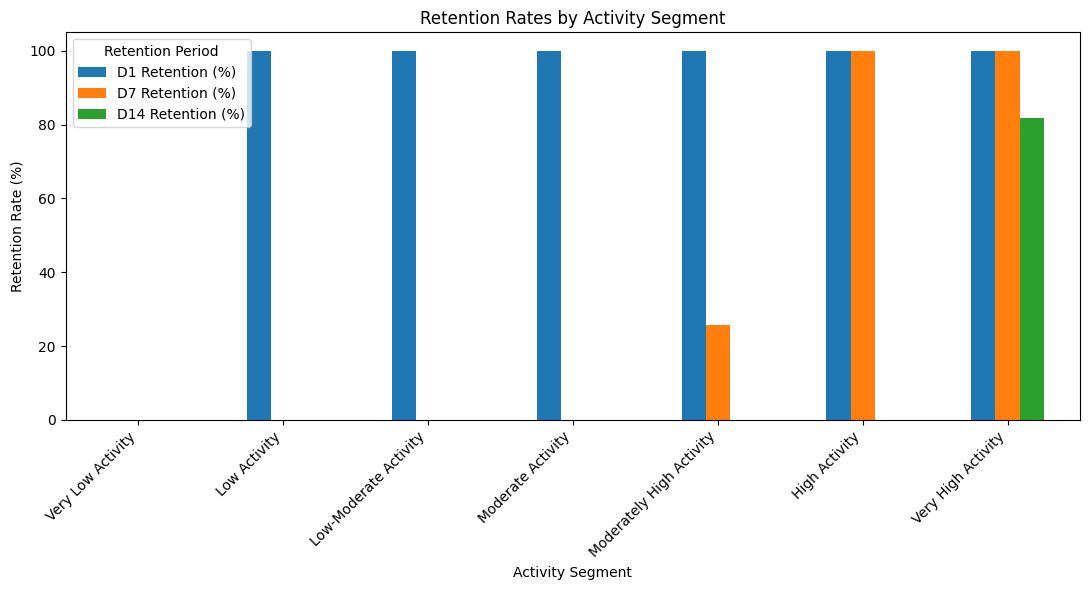


EARLY ACTIVITY D0-D3:


,user_id,early_active_days
0,1,4
1,2,4
2,3,4
3,4,2
4,5,4



D7 RETENTION BY EARLY ACTIVITY:


,players,d7_retained,d7_retention_pct
early_active_days,,,
1,906,0,0.00
2,763,0,0.00
3,635,0,0.00
4,2696,1211,44.92



EARLY ACTIVITY D0-D6:


,user_id,early_active_days_d0_d6
0,1,6
1,2,4
2,3,7
3,4,2
4,5,6



Minimum D0-D6 active days: 1
Maximum D0-D6 active days: 7

D14 RETENTION BY EARLY ACTIVITY D0-D6:


,players,d14_retained,d14_retention_pct
early_active_days_d0_d6,,,
1,906,0,0.00
2,763,0,0.00
3,635,0,0.00
4,493,0,0.00
5,409,0,0.00
6,336,0,0.00
7,1458,313,21.47


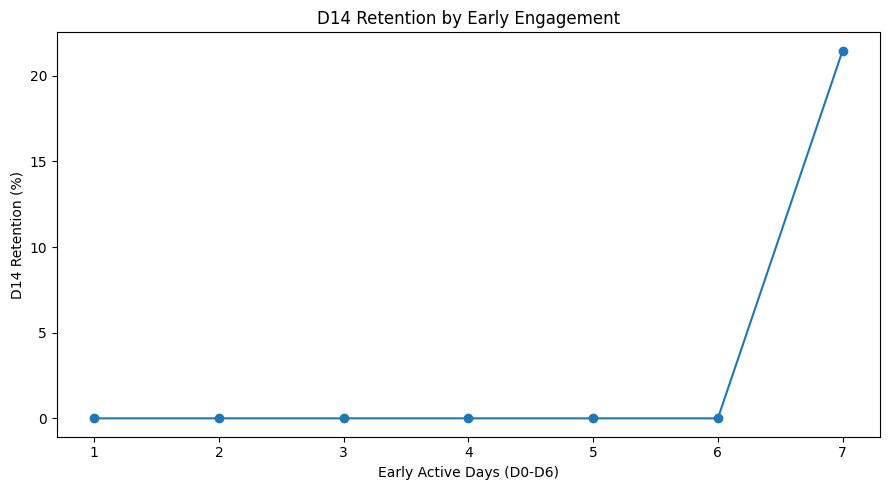


CORRELATION: EARLY ACTIVITY VS D7 RETENTION


,early_active_days,d7_retained
early_active_days,1.000000,0.463593
d7_retained,0.463593,1.000000



CORRELATION: EARLY ACTIVITY VS D14 RETENTION


,early_active_days_d0_d6,d14_retained
early_active_days_d0_d6,1.000000,0.322909
d14_retained,0.322909,1.000000



PHASE 4 PART 5 COMPLETE
Number of players: 5000
Number of activity segments: 7
D1 retained: 4094
D7 retained: 1211
D14 retained: 313
Maximum D0-D6 active days: 7
Missing D0-D6 activity: 0


In [382]:
# RETENTION BY ACTIVITY SEGMENT & EARLY ENGAGEMENT

# ============================================================
# 1. RECREATE RETENTION INDICATORS
# ============================================================

d1_users = set(
    player_day.loc[
        player_day["days_since_install"] == 1,
        "user_id"
    ]
)

d7_users = set(
    player_day.loc[
        player_day["days_since_install"] == 7,
        "user_id"
    ]
)

d14_users = set(
    player_day.loc[
        player_day["days_since_install"] == 14,
        "user_id"
    ]
)

for col in ["d1_retained", "d7_retained", "d14_retained"]:
    if col in player_stats.columns:
        player_stats = player_stats.drop(columns=[col])

player_stats["d1_retained"] = (
    player_stats["user_id"]
    .isin(d1_users)
    .astype(int)
)

player_stats["d7_retained"] = (
    player_stats["user_id"]
    .isin(d7_users)
    .astype(int)
)

player_stats["d14_retained"] = (
    player_stats["user_id"]
    .isin(d14_users)
    .astype(int)
)

print("RETENTION COUNTS:")

print("\nD1:")
print(player_stats["d1_retained"].value_counts())

print("\nD7:")
print(player_stats["d7_retained"].value_counts())

print("\nD14:")
print(player_stats["d14_retained"].value_counts())


# ============================================================
# 2. RETENTION BY ACTIVITY SEGMENT
# ============================================================

if "activity_segment" not in player_stats.columns:
    raise ValueError(
        "activity_segment is missing. Run Phase 4 Part 4 first."
    )

retention_by_segment = (
    player_stats
    .groupby("activity_segment")
    .agg(
        players=("user_id", "count"),
        d1_retained=("d1_retained", "sum"),
        d7_retained=("d7_retained", "sum"),
        d14_retained=("d14_retained", "sum")
    )
)

retention_by_segment["d1_retention_pct"] = (
    retention_by_segment["d1_retained"]
    / retention_by_segment["players"]
    * 100
)

retention_by_segment["d7_retention_pct"] = (
    retention_by_segment["d7_retained"]
    / retention_by_segment["players"]
    * 100
)

retention_by_segment["d14_retention_pct"] = (
    retention_by_segment["d14_retained"]
    / retention_by_segment["players"]
    * 100
)

segment_order = [
    "Very Low Activity",
    "Low Activity",
    "Low-Moderate Activity",
    "Moderate Activity",
    "Moderately High Activity",
    "High Activity",
    "Very High Activity"
]

retention_by_segment = retention_by_segment.reindex(segment_order)

print("\nRETENTION BY ACTIVITY SEGMENT:")

display(
    retention_by_segment.round(2)
)


# ============================================================
# 3. FINAL RETENTION TABLE
# ============================================================

segment_retention_table = (
    retention_by_segment[
        [
            "players",
            "d1_retention_pct",
            "d7_retention_pct",
            "d14_retention_pct"
        ]
    ]
    .copy()
)

segment_retention_table.columns = [
    "Players",
    "D1 Retention (%)",
    "D7 Retention (%)",
    "D14 Retention (%)"
]

print("\nFINAL SEGMENT RETENTION TABLE:")

display(
    segment_retention_table.round(2)
)


# ============================================================
# 4. RETENTION VISUALIZATION
# ============================================================

segment_retention_table[
    [
        "D1 Retention (%)",
        "D7 Retention (%)",
        "D14 Retention (%)"
    ]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.xlabel("Activity Segment")
plt.ylabel("Retention Rate (%)")
plt.title("Retention Rates by Activity Segment")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Retention Period")
plt.tight_layout()
plt.show()


# ============================================================
# 5. EARLY ACTIVITY D0-D3 VS D7 RETENTION
# ============================================================

for col in ["early_active_days"]:
    if col in player_stats.columns:
        player_stats = player_stats.drop(columns=[col])

early_activity_d7 = (
    player_day[
        player_day["days_since_install"].between(0, 3)
    ]
    .groupby("user_id")["days_since_install"]
    .nunique()
    .reset_index(name="early_active_days")
)

player_stats = player_stats.merge(
    early_activity_d7,
    on="user_id",
    how="left"
)

player_stats["early_active_days"] = (
    player_stats["early_active_days"]
    .fillna(0)
    .astype(int)
)

print("\nEARLY ACTIVITY D0-D3:")

display(
    player_stats[
        ["user_id", "early_active_days"]
    ].head()
)


# ============================================================
# 6. D7 RETENTION BY EARLY ACTIVITY
# ============================================================

d7_by_early_activity = (
    player_stats
    .groupby("early_active_days")
    .agg(
        players=("user_id", "count"),
        d7_retained=("d7_retained", "sum")
    )
)

d7_by_early_activity["d7_retention_pct"] = (
    d7_by_early_activity["d7_retained"]
    / d7_by_early_activity["players"]
    * 100
)

print("\nD7 RETENTION BY EARLY ACTIVITY:")

display(
    d7_by_early_activity.round(2)
)


# ============================================================
# 7. EARLY ACTIVITY D0-D6 VS D14 RETENTION
# ============================================================

if "early_active_days_d0_d6" in player_stats.columns:
    player_stats = player_stats.drop(
        columns=["early_active_days_d0_d6"]
    )

early_activity_d14 = (
    player_day[
        player_day["days_since_install"].between(0, 6)
    ]
    .groupby("user_id")["days_since_install"]
    .nunique()
    .reset_index(
        name="early_active_days_d0_d6"
    )
)

player_stats = player_stats.merge(
    early_activity_d14,
    on="user_id",
    how="left"
)

player_stats["early_active_days_d0_d6"] = (
    player_stats["early_active_days_d0_d6"]
    .fillna(0)
    .astype(int)
)

print("\nEARLY ACTIVITY D0-D6:")

display(
    player_stats[
        [
            "user_id",
            "early_active_days_d0_d6"
        ]
    ].head()
)

print(
    "\nMinimum D0-D6 active days:",
    player_stats["early_active_days_d0_d6"].min()
)

print(
    "Maximum D0-D6 active days:",
    player_stats["early_active_days_d0_d6"].max()
)


# ============================================================
# 8. D14 RETENTION BY EARLY ACTIVITY
# ============================================================

d14_by_early_activity = (
    player_stats
    .groupby("early_active_days_d0_d6")
    .agg(
        players=("user_id", "count"),
        d14_retained=("d14_retained", "sum")
    )
)

d14_by_early_activity["d14_retention_pct"] = (
    d14_by_early_activity["d14_retained"]
    / d14_by_early_activity["players"]
    * 100
)

print("\nD14 RETENTION BY EARLY ACTIVITY D0-D6:")

display(
    d14_by_early_activity.round(2)
)


# ============================================================
# 9. D14 RETENTION VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    d14_by_early_activity.index,
    d14_by_early_activity["d14_retention_pct"],
    marker="o"
)

plt.xlabel("Early Active Days (D0-D6)")
plt.ylabel("D14 Retention (%)")
plt.title("D14 Retention by Early Engagement")
plt.xticks(
    d14_by_early_activity.index
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. CORRELATION: EARLY ACTIVITY VS D7 RETENTION
# ============================================================

d7_correlation = (
    player_stats[
        [
            "early_active_days",
            "d7_retained"
        ]
    ]
    .corr()
)

print(
    "\nCORRELATION: EARLY ACTIVITY VS D7 RETENTION"
)

display(d7_correlation)


# ============================================================
# 11. CORRELATION: EARLY ACTIVITY VS D14 RETENTION
# ============================================================

d14_correlation = (
    player_stats[
        [
            "early_active_days_d0_d6",
            "d14_retained"
        ]
    ]
    .corr()
)

print(
    "\nCORRELATION: EARLY ACTIVITY VS D14 RETENTION"
)

display(d14_correlation)


# ============================================================
# 12. FINAL VALIDATION
# ============================================================

print("\n========================================")
print("PHASE 4 PART 5 COMPLETE")
print("========================================")

print(
    "Number of players:",
    len(player_stats)
)

print(
    "Number of activity segments:",
    player_stats["activity_segment"].nunique()
)

print(
    "D1 retained:",
    player_stats["d1_retained"].sum()
)

print(
    "D7 retained:",
    player_stats["d7_retained"].sum()
)

print(
    "D14 retained:",
    player_stats["d14_retained"].sum()
)

print(
    "Maximum D0-D6 active days:",
    player_stats["early_active_days_d0_d6"].max()
)

print(
    "Missing D0-D6 activity:",
    player_stats["early_active_days_d0_d6"].isnull().sum()
)

In [383]:
events=pd.read_excel(r"C:\Users\HOME\Desktop\project#3\events.xlsx")
users=pd.read_excel(r"C:\Users\HOME\Desktop\project#3\users.xlsx")

users["install_date"] = pd.to_datetime(users["install_date"])
events["event_date"] = pd.to_datetime(events["event_date"])

# Create master event table
master_events = events.merge(users, on="user_id", how="left")

master_events["days_since_install"] = (
    master_events["event_date"] - master_events["install_date"]
).dt.days

# Dataset observation end
observation_end = master_events["event_date"].max()

# Eligible players: complete D7-D13 follow-up window
users["eligible_for_churn"] = (
    users["install_date"] + pd.Timedelta(days=13) <= observation_end
)

eligible_users = users.loc[
    users["eligible_for_churn"],
    ["user_id", "install_date"]
].copy()

# Feature window: D0-D6
feature_events = master_events[
    (master_events["days_since_install"] >= 0) &
    (master_events["days_since_install"] <= 6)
].copy()

# Churn window: D7-D13
churn_window_events = master_events[
    (master_events["days_since_install"] >= 7) &
    (master_events["days_since_install"] <= 13)
].copy()

# Keep only eligible players
feature_events = feature_events[
    feature_events["user_id"].isin(eligible_users["user_id"])
]

churn_window_events = churn_window_events[
    churn_window_events["user_id"].isin(eligible_users["user_id"])
]

# Define churn
players_active_in_churn_window = set(
    churn_window_events["user_id"].unique()
)

eligible_users["churned"] = (
    ~eligible_users["user_id"].isin(players_active_in_churn_window)
).astype(int)

In [384]:

print("Observation end date:", observation_end.date())
print("Total players:", len(users))
print("Eligible players:", len(eligible_users))
print("Excluded players:", len(users) - len(eligible_users))

print("\nChurn distribution:")
print(eligible_users["churned"].value_counts().sort_index())

print("\nChurn percentage:")
print(
    eligible_users["churned"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nEligibility date range:")
print("Earliest eligible install:", eligible_users["install_date"].min().date())
print("Latest eligible install:", eligible_users["install_date"].max().date())

print("\nValidation:")
print("Missing churn labels:", eligible_users["churned"].isna().sum())
print("Unique players:", eligible_users["user_id"].nunique())

Observation end date: 2024-03-05
Total players: 5000
Eligible players: 5000
Excluded players: 0

Churn distribution:
churned
0    1211
1    3789
Name: count, dtype: int64

Churn percentage:
churned
0    24.22
1    75.78
Name: proportion, dtype: float64

Eligibility date range:
Earliest eligible install: 2024-01-01
Latest eligible install: 2024-01-30

Validation:
Missing churn labels: 0
Unique players: 5000


In [385]:
# Create early engagement features from D0-D6
early_features = (
    feature_events
    .groupby("user_id")
    .agg(
        early_sessions_d0_d6=("event_date", "count"),
        early_active_days_d0_d6=("event_date", "nunique")
    )
    .reset_index()
)

# Create final churn dataset
churn_data = (
    eligible_users[
        ["user_id", "install_date", "churned"]
    ]
    .merge(
        early_features,
        on="user_id",
        how="left"
    )
)

# Players with no D0-D6 activity
churn_data[
    ["early_sessions_d0_d6", "early_active_days_d0_d6"]
] = churn_data[
    ["early_sessions_d0_d6", "early_active_days_d0_d6"]
].fillna(0)

In [386]:
# Target distribution
print(churn_data["churned"].value_counts().sort_index())

churned
0    1211
1    3789
Name: count, dtype: int64


In [387]:
# TARGET PERCENTAGE
print(
    churn_data["churned"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

churned
0    24.22
1    75.78
Name: proportion, dtype: float64


In [388]:
# Early behavior by churn status
print("\n=== EARLY BEHAVIOR BY CHURN STATUS ===")
print(
    churn_data
    .groupby("churned")[
        ["early_sessions_d0_d6", "early_active_days_d0_d6"]
    ]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)


=== EARLY BEHAVIOR BY CHURN STATUS ===
        early_sessions_d0_d6                      early_active_days_d0_d6  \
                       count  mean median min max                   count   
churned                                                                     
0                       1211  7.00    7.0   7   7                    1211   
1                       3789  3.19    3.0   1   7                    3789   

                              
         mean median min max  
churned                       
0        7.00    7.0   7   7  
1        3.19    3.0   1   7  


In [389]:
# Churn rate by early active days
churn_by_activity = (
    churn_data
    .groupby("early_active_days_d0_d6")
    .agg(
        players=("user_id", "count"),
        churned_players=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

churn_by_activity["churn_rate"] = (
    churn_by_activity["churn_rate"] * 100
).round(2)

print("\n=== CHURN BY EARLY ACTIVE DAYS ===")
print(churn_by_activity)

# Validation
print("\n=== VALIDATION ===")
print("Rows:", len(churn_data))
print("Unique players:", churn_data["user_id"].nunique())
print("Missing churn labels:", churn_data["churned"].isna().sum())
print("Duplicate user IDs:", churn_data["user_id"].duplicated().sum())
print(
    "Missing feature values:",
    churn_data[
        ["early_sessions_d0_d6", "early_active_days_d0_d6"]
    ].isna().sum().sum()
)
print(
    "Minimum early active days:",
    churn_data["early_active_days_d0_d6"].min()
)
print(
    "Maximum early active days:",
    churn_data["early_active_days_d0_d6"].max()
)


=== CHURN BY EARLY ACTIVE DAYS ===
   early_active_days_d0_d6  players  churned_players  churn_rate
0                        1      906              906      100.00
1                        2      763              763      100.00
2                        3      635              635      100.00
3                        4      493              493      100.00
4                        5      409              409      100.00
5                        6      336              336      100.00
6                        7     1458              247       16.94

=== VALIDATION ===
Rows: 5000
Unique players: 5000
Missing churn labels: 0
Duplicate user IDs: 0
Missing feature values: 0
Minimum early active days: 1
Maximum early active days: 7


In [390]:
# Work only with the D0-D6 feature window
early = feature_events.copy()

# Create calendar-day information
early["day_of_week"] = early["event_date"].dt.dayofweek
early["is_weekend"] = (early["day_of_week"] >= 5).astype(int)

# Player-level predictive features
predictive_features = (
    early
    .groupby("user_id")
    .agg(
        early_sessions=("event_date", "count"),
        early_active_days=("event_date", "nunique"),
        early_first_activity_day=("days_since_install", "min"),
        early_last_activity_day=("days_since_install", "max"),
        early_weekend_days=("is_weekend", "sum")
    )
    .reset_index()
)

# Derived features
predictive_features["early_activity_rate"] = (
    predictive_features["early_active_days"] / 7
)

predictive_features["early_recency"] = (
    6 - predictive_features["early_last_activity_day"]
)

# Combine with churn target
model_data = (
    churn_data[
        ["user_id", "churned"]
    ]
    .merge(
        predictive_features,
        on="user_id",
        how="left"
    )
)

# Handle players with no early activity
feature_columns = [
    "early_sessions",
    "early_active_days",
    "early_first_activity_day",
    "early_last_activity_day",
    "early_weekend_days",
    "early_activity_rate",
    "early_recency"
]

model_data[feature_columns] = (
    model_data[feature_columns].fillna(0)
)

# Feature summary
print("=== FEATURE SUMMARY ===")
print(
    model_data[feature_columns]
    .describe()
    .round(2)
)

# Correlation matrix
print("\n=== FEATURE CORRELATION ===")
print(
    model_data[feature_columns]
    .corr()
    .round(2)
)

# Correlation with churn
print("\n=== FEATURE-TARGET CORRELATION ===")
print(
    model_data[
        feature_columns + ["churned"]
    ]
    .corr()["churned"]
    .drop("churned")
    .sort_values()
    .round(3)
)

# Missing-value check
print("\n=== VALIDATION ===")
print(
    "Missing feature values:",
    model_data[feature_columns].isna().sum().sum()
)

print(
    "Rows:",
    len(model_data)
)

print(
    "Unique players:",
    model_data["user_id"].nunique()
)

=== FEATURE SUMMARY ===
       early_sessions  early_active_days  early_first_activity_day  \
count         5000.00            5000.00                    5000.0   
mean             4.12               4.12                       0.0   
std              2.31               2.31                       0.0   
min              1.00               1.00                       0.0   
25%              2.00               2.00                       0.0   
50%              4.00               4.00                       0.0   
75%              7.00               7.00                       0.0   
max              7.00               7.00                       0.0   

       early_last_activity_day  early_weekend_days  early_activity_rate  \
count                  5000.00             5000.00              5000.00   
mean                      3.12                1.13                 0.59   
std                       2.31                0.89                 0.33   
min                       0.00               

In [391]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Final candidate features
selected_features = [
    "early_active_days",
    "early_weekend_days"
]

X = model_data[selected_features]
y = model_data["churned"]

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check class distribution
print("=== DATA SPLIT ===")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining churn distribution:")
print(
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTesting churn distribution:")
print(
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Baseline model
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]

# Baseline evaluation
baseline_results = {
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Precision": precision_score(y_test, y_pred_baseline, zero_division=0),
    "Recall": recall_score(y_test, y_pred_baseline, zero_division=0),
    "F1": f1_score(y_test, y_pred_baseline, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_baseline),
    "PR-AUC": average_precision_score(y_test, y_prob_baseline)
}

print("\n=== BASELINE PERFORMANCE ===")
for metric, value in baseline_results.items():
    print(f"{metric}: {value:.4f}")

print("\n=== BASELINE CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred_baseline))

=== DATA SPLIT ===
Training samples: 4000
Testing samples: 1000

Training churn distribution:
churned
0    24.22
1    75.78
Name: proportion, dtype: float64

Testing churn distribution:
churned
0    24.2
1    75.8
Name: proportion, dtype: float64

=== BASELINE PERFORMANCE ===
Accuracy: 0.7580
Precision: 0.7580
Recall: 1.0000
F1: 0.8623
ROC-AUC: 0.5000
PR-AUC: 0.7580

=== BASELINE CONFUSION MATRIX ===
[[  0 242]
 [  0 758]]


In [392]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Logistic Regression pipeline
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train model
logistic_model.fit(X_train, y_train)

# Predictions
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

# Evaluation
logistic_results = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr, zero_division=0),
    "Recall": recall_score(y_test, y_pred_lr, zero_division=0),
    "F1": f1_score(y_test, y_pred_lr, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr),
    "PR-AUC": average_precision_score(y_test, y_prob_lr)
}

print("=== LOGISTIC REGRESSION PERFORMANCE ===")
for metric, value in logistic_results.items():
    print(f"{metric}: {value:.4f}")

print("\n=== LOGISTIC REGRESSION CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred_lr))

# Model coefficients
lr_model = logistic_model.named_steps["model"]

coefficient_table = (
    pd.DataFrame({
        "Feature": selected_features,
        "Coefficient": lr_model.coef_[0]
    })
    .sort_values("Coefficient")
)

print("\n=== LOGISTIC REGRESSION COEFFICIENTS ===")
print(coefficient_table.to_string(index=False))

# Intercept
print("\nIntercept:", round(lr_model.intercept_[0], 4))

=== LOGISTIC REGRESSION PERFORMANCE ===
Accuracy: 0.9520
Precision: 1.0000
Recall: 0.9367
F1: 0.9673
ROC-AUC: 0.9683
PR-AUC: 0.9847

=== LOGISTIC REGRESSION CONFUSION MATRIX ===
[[242   0]
 [ 48 710]]

=== LOGISTIC REGRESSION COEFFICIENTS ===
           Feature  Coefficient
 early_active_days    -8.639481
early_weekend_days    -1.636897

Intercept: 10.8807


In [393]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
rf_results = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "F1": f1_score(y_test, y_pred_rf, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf),
    "PR-AUC": average_precision_score(y_test, y_prob_rf)
}

print("=== RANDOM FOREST PERFORMANCE ===")
for metric, value in rf_results.items():
    print(f"{metric}: {value:.4f}")

print("\n=== RANDOM FOREST CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred_rf))

# Feature importance
rf_importance = (
    pd.DataFrame({
        "Feature": selected_features,
        "Importance": rf_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

print("\n=== RANDOM FOREST FEATURE IMPORTANCE ===")
print(rf_importance.to_string(index=False))

# Model comparison
model_comparison = pd.DataFrame({
    "Dummy Baseline": baseline_results,
    "Logistic Regression": logistic_results,
    "Random Forest": rf_results
}).T

print("\n=== MODEL COMPARISON ===")
print(model_comparison.round(4))

=== RANDOM FOREST PERFORMANCE ===
Accuracy: 0.9520
Precision: 1.0000
Recall: 0.9367
F1: 0.9673
ROC-AUC: 0.9683
PR-AUC: 0.9847

=== RANDOM FOREST CONFUSION MATRIX ===
[[242   0]
 [ 48 710]]

=== RANDOM FOREST FEATURE IMPORTANCE ===
           Feature  Importance
 early_active_days    0.710893
early_weekend_days    0.289107

=== MODEL COMPARISON ===
                     Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
Dummy Baseline          0.758      0.758  1.0000  0.8623   0.5000  0.7580
Logistic Regression     0.952      1.000  0.9367  0.9673   0.9683  0.9847
Random Forest           0.952      1.000  0.9367  0.9673   0.9683  0.9847


In [394]:
# Create test-set risk dataframe
risk_data = X_test.copy()

risk_data["actual_churn"] = y_test.values
risk_data["predicted_churn_probability"] = y_prob_lr

# Assign risk tiers
risk_data["risk_tier"] = pd.cut(
    risk_data["predicted_churn_probability"],
    bins=[-np.inf, 0.30, 0.70, np.inf],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Risk tier distribution
print("=== RISK TIER DISTRIBUTION ===")
print(
    risk_data["risk_tier"]
    .value_counts()
    .sort_index()
)

print("\n=== RISK TIER PERCENTAGE ===")
print(
    risk_data["risk_tier"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Actual churn rate within each predicted risk tier
risk_summary = (
    risk_data
    .groupby("risk_tier", observed=False)
    .agg(
        players=("actual_churn", "count"),
        actual_churned=("actual_churn", "sum"),
        average_predicted_risk=(
            "predicted_churn_probability",
            "mean"
        ),
        actual_churn_rate=("actual_churn", "mean")
    )
    .reset_index()
)

risk_summary["actual_churn_rate"] = (
    risk_summary["actual_churn_rate"] * 100
).round(2)

risk_summary["average_predicted_risk"] = (
    risk_summary["average_predicted_risk"] * 100
).round(2)

print("\n=== RISK TIER VALIDATION ===")
print(risk_summary)

# Behavioral profile by risk tier
risk_behavior = (
    risk_data
    .groupby("risk_tier", observed=False)[selected_features]
    .agg(["mean", "median"])
    .round(2)
)

print("\n=== BEHAVIOR BY RISK TIER ===")
print(risk_behavior)

# Risk probability summary
print("\n=== PREDICTED RISK SUMMARY ===")
print(
    risk_data["predicted_churn_probability"]
    .describe()
    .round(3)
)

# Validation
print("\n=== VALIDATION ===")
print(
    "Missing predicted probabilities:",
    risk_data["predicted_churn_probability"].isna().sum()
)

print(
    "Missing risk tiers:",
    risk_data["risk_tier"].isna().sum()
)

print(
    "Players in risk analysis:",
    len(risk_data)
)

=== RISK TIER DISTRIBUTION ===
risk_tier
Low Risk       290
Medium Risk      0
High Risk      710
Name: count, dtype: int64

=== RISK TIER PERCENTAGE ===
risk_tier
Low Risk       29.0
Medium Risk     0.0
High Risk      71.0
Name: proportion, dtype: float64

=== RISK TIER VALIDATION ===
     risk_tier  players  actual_churned  average_predicted_risk  \
0     Low Risk      290              48                   18.70   
1  Medium Risk        0               0                     NaN   
2    High Risk      710             710                   99.37   

   actual_churn_rate  
0              16.55  
1                NaN  
2             100.00  

=== BEHAVIOR BY RISK TIER ===
            early_active_days        early_weekend_days       
                         mean median               mean median
risk_tier                                                     
Low Risk                 7.00    7.0               2.00    2.0
Medium Risk               NaN    NaN                NaN    NaN
High R

In [395]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

# Training performance
y_pred_lr_train = logistic_model.predict(X_train)
y_prob_lr_train = logistic_model.predict_proba(X_train)[:, 1]

y_pred_rf_train = rf_model.predict(X_train)
y_prob_rf_train = rf_model.predict_proba(X_train)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }

train_lr_results = get_metrics(
    y_train,
    y_pred_lr_train,
    y_prob_lr_train
)

train_rf_results = get_metrics(
    y_train,
    y_pred_rf_train,
    y_prob_rf_train
)

print("=== TRAINING PERFORMANCE ===")

print("\nLogistic Regression:")
for metric, value in train_lr_results.items():
    print(f"{metric}: {value:.4f}")

print("\nRandom Forest:")
for metric, value in train_rf_results.items():
    print(f"{metric}: {value:.4f}")


# Test performance
test_lr_results = logistic_results
test_rf_results = rf_results

print("\n=== TEST PERFORMANCE ===")

print("\nLogistic Regression:")
for metric, value in test_lr_results.items():
    print(f"{metric}: {value:.4f}")

print("\nRandom Forest:")
for metric, value in test_rf_results.items():
    print(f"{metric}: {value:.4f}")


# Train-test comparison
comparison = pd.DataFrame({
    "Logistic Regression Train": train_lr_results,
    "Logistic Regression Test": test_lr_results,
    "Random Forest Train": train_rf_results,
    "Random Forest Test": test_rf_results
})

print("\n=== TRAIN VS TEST COMPARISON ===")
print(comparison.round(4))


# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

rf_cv_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

lr_cv = cross_validate(
    lr_cv_model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

rf_cv = cross_validate(
    rf_cv_model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

cv_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Logistic Regression Mean": [
        lr_cv["test_accuracy"].mean(),
        lr_cv["test_precision"].mean(),
        lr_cv["test_recall"].mean(),
        lr_cv["test_f1"].mean(),
        lr_cv["test_roc_auc"].mean(),
        lr_cv["test_pr_auc"].mean()
    ],
    "Logistic Regression Std": [
        lr_cv["test_accuracy"].std(),
        lr_cv["test_precision"].std(),
        lr_cv["test_recall"].std(),
        lr_cv["test_f1"].std(),
        lr_cv["test_roc_auc"].std(),
        lr_cv["test_pr_auc"].std()
    ],
    "Random Forest Mean": [
        rf_cv["test_accuracy"].mean(),
        rf_cv["test_precision"].mean(),
        rf_cv["test_recall"].mean(),
        rf_cv["test_f1"].mean(),
        rf_cv["test_roc_auc"].mean(),
        rf_cv["test_pr_auc"].mean()
    ],
    "Random Forest Std": [
        rf_cv["test_accuracy"].std(),
        rf_cv["test_precision"].std(),
        rf_cv["test_recall"].std(),
        rf_cv["test_f1"].std(),
        rf_cv["test_roc_auc"].std(),
        rf_cv["test_pr_auc"].std()
    ]
})

print("\n=== 5-FOLD CROSS-VALIDATION ===")
print(cv_results.round(4))


# Leakage validation
print("\n=== TEMPORAL LEAKAGE CHECK ===")
print("Feature window: D0-D6")
print("Target window: D7-D13")
print("Features used:", selected_features)

print(
    "\nMaximum feature day:",
    feature_events["days_since_install"].max()
)

print(
    "Minimum outcome day:",
    churn_window_events["days_since_install"].min()
)

print(
    "Temporal separation valid:",
    feature_events["days_since_install"].max()
    < churn_window_events["days_since_install"].min()
)

=== TRAINING PERFORMANCE ===

Logistic Regression:
Accuracy: 0.9503
Precision: 1.0000
Recall: 0.9343
F1: 0.9661
ROC-AUC: 0.9672
PR-AUC: 0.9841

Random Forest:
Accuracy: 0.9503
Precision: 1.0000
Recall: 0.9343
F1: 0.9661
ROC-AUC: 0.9672
PR-AUC: 0.9841

=== TEST PERFORMANCE ===

Logistic Regression:
Accuracy: 0.9520
Precision: 1.0000
Recall: 0.9367
F1: 0.9673
ROC-AUC: 0.9683
PR-AUC: 0.9847

Random Forest:
Accuracy: 0.9520
Precision: 1.0000
Recall: 0.9367
F1: 0.9673
ROC-AUC: 0.9683
PR-AUC: 0.9847

=== TRAIN VS TEST COMPARISON ===
           Logistic Regression Train  Logistic Regression Test  \
Accuracy                      0.9502                    0.9520   
Precision                     1.0000                    1.0000   
Recall                        0.9343                    0.9367   
F1                            0.9661                    0.9673   
ROC-AUC                       0.9672                    0.9683   
PR-AUC                        0.9841                    0.9847   

    

In [396]:
overall_insights = {
    "Total Players": player_stats["user_id"].nunique(),
    "Total Events": len(master_events),
    "Median Sessions per Player": player_stats["total_sessions"].median(),
    "Median Active Days per Player": player_stats["active_days"].median(),
    "Mean Sessions per Player": player_stats["total_sessions"].mean(),
    "Mean Active Days per Player": player_stats["active_days"].mean(),
    "P90 Sessions": player_stats["total_sessions"].quantile(0.90),
    "P95 Sessions": player_stats["total_sessions"].quantile(0.95),
    "P99 Sessions": player_stats["total_sessions"].quantile(0.99),
    "D1 Retention (%)": player_stats["d1_retained"].mean() * 100,
    "D7 Retention (%)": player_stats["d7_retained"].mean() * 100,
    "D14 Retention (%)": player_stats["d14_retained"].mean() * 100
}

overall_insights_df = pd.DataFrame(
    list(overall_insights.items()),
    columns=["Metric", "Value"]
)

print("OVERALL PLAYER & ENGAGEMENT INSIGHTS")
print("=" * 50)
print(overall_insights_df.to_string(index=False))

print("\nKEY ENGAGEMENT DISTRIBUTION")
print("=" * 50)

print(f"Median sessions per player: {player_stats['total_sessions'].median():.0f}")
print(f"Median active days per player: {player_stats['active_days'].median():.0f}")
print(f"90th percentile sessions: {player_stats['total_sessions'].quantile(0.90):.0f}")
print(f"95th percentile sessions: {player_stats['total_sessions'].quantile(0.95):.0f}")
print(f"99th percentile sessions: {player_stats['total_sessions'].quantile(0.99):.0f}")

print("\nENGAGEMENT DISTRIBUTION")
print("=" * 50)

engagement_distribution = (
    player_stats["total_sessions"]
    .value_counts()
    .sort_index()
    .head(15)
    .reset_index()
)

engagement_distribution.columns = ["Total Sessions", "Players"]

print(engagement_distribution.to_string(index=False))

print("\nSKEWNESS")
print("=" * 50)

print(
    f"Sessions skewness: "
    f"{player_stats['total_sessions'].skew():.3f}"
)

print(
    f"Active days skewness: "
    f"{player_stats['active_days'].skew():.3f}"
)

print("\nOUTLIER CHECK")
print("=" * 50)

q1 = player_stats["total_sessions"].quantile(0.25)
q3 = player_stats["total_sessions"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outlier_count = (player_stats["total_sessions"] > upper_bound).sum()

print(f"Q1 sessions: {q1:.0f}")
print(f"Q3 sessions: {q3:.0f}")
print(f"IQR: {iqr:.0f}")
print(f"Upper outlier bound: {upper_bound:.1f}")
print(f"Potential high-engagement outliers: {outlier_count}")

print("\nBUSINESS OBSERVATIONS")
print("=" * 50)

print("1. Player engagement is concentrated toward lower activity levels.")
print("2. Session and active-day distributions are right-skewed, indicating a smaller group of highly active players.")
print("3. The median player has relatively limited recorded activity compared with the most active players.")
print("4. Retention declines substantially as the time since installation increases.")
print("5. Early engagement provides useful information for understanding later player behavior.")

OVERALL PLAYER & ENGAGEMENT INSIGHTS
                       Metric      Value
                Total Players  5000.0000
                 Total Events 27291.0000
   Median Sessions per Player     4.0000
Median Active Days per Player     4.0000
     Mean Sessions per Player     5.4582
  Mean Active Days per Player     5.4582
                 P90 Sessions    12.0000
                 P95 Sessions    15.0000
                 P99 Sessions    23.0000
             D1 Retention (%)    81.8800
             D7 Retention (%)    24.2200
            D14 Retention (%)     6.2600

KEY ENGAGEMENT DISTRIBUTION
Median sessions per player: 4
Median active days per player: 4
90th percentile sessions: 12
95th percentile sessions: 15
99th percentile sessions: 23

ENGAGEMENT DISTRIBUTION
 Total Sessions  Players
              1      906
              2      763
              3      635
              4      493
              5      409
              6      336
              7      247
              8      203
 

In [397]:

early_d0_d3 = (
    player_day[player_day["days_since_install"].between(0, 3)]
    .groupby("user_id")["days_since_install"]
    .nunique()
    .rename("early_active_days_d0_d3")
)

early_d0_d6 = (
    player_day[player_day["days_since_install"].between(0, 6)]
    .groupby("user_id")["days_since_install"]
    .nunique()
    .rename("early_active_days_d0_d6")
)

player_stats = player_stats.drop(
    columns=["early_active_days_d0_d3", "early_active_days_d0_d6"],
    errors="ignore"
)

player_stats = player_stats.merge(early_d0_d3, on="user_id", how="left")
player_stats = player_stats.merge(early_d0_d6, on="user_id", how="left")

player_stats[["early_active_days_d0_d3", "early_active_days_d0_d6"]] = (
    player_stats[["early_active_days_d0_d3", "early_active_days_d0_d6"]]
    .fillna(0)
)

churn_early_days = (
    churn_data[["user_id", "churned"]]
    .merge(
        player_stats[["user_id", "early_active_days_d0_d6"]],
        on="user_id",
        how="left"
    )
    .rename(columns={"early_active_days_d0_d6": "early_active_days"})
)

retention_summary = pd.DataFrame({
    "Metric": [
        "D1 Retention",
        "D7 Retention",
        "D14 Retention",
        "Churn Rate (D7-D13)",
        "Non-Churn Rate (D7-D13)"
    ],
    "Percentage": [
        player_stats["d1_retained"].mean() * 100,
        player_stats["d7_retained"].mean() * 100,
        player_stats["d14_retained"].mean() * 100,
        churn_data["churned"].mean() * 100,
        (1 - churn_data["churned"].mean()) * 100
    ]
})

print("RETENTION & CHURN SUMMARY")
print("=" * 50)
print(retention_summary.to_string(index=False))

print("\nRETENTION COUNTS")
print("=" * 50)

print(f"D1 retained: {player_stats['d1_retained'].sum()} / {len(player_stats)}")
print(f"D7 retained: {player_stats['d7_retained'].sum()} / {len(player_stats)}")
print(f"D14 retained: {player_stats['d14_retained'].sum()} / {len(player_stats)}")

print("\nEARLY ENGAGEMENT vs RETENTION")
print("=" * 50)

print(
    f"D0-D3 active days vs D7 retention correlation: "
    f"{player_stats['early_active_days_d0_d3'].corr(player_stats['d7_retained']):.3f}"
)

print(
    f"D0-D6 active days vs D14 retention correlation: "
    f"{player_stats['early_active_days_d0_d6'].corr(player_stats['d14_retained']):.3f}"
)

print("\nD7 RETENTION BY EARLY ACTIVITY")
print("=" * 50)

d7_early_summary = (
    player_stats
    .groupby("early_active_days_d0_d3")
    .agg(
        players=("user_id", "count"),
        retained=("d7_retained", "sum"),
        retention_rate=("d7_retained", "mean")
    )
    .reset_index()
)

d7_early_summary["retention_rate"] *= 100

print(d7_early_summary.to_string(index=False))

print("\nD14 RETENTION BY EARLY ACTIVITY")
print("=" * 50)

d14_early_summary = (
    player_stats
    .groupby("early_active_days_d0_d6")
    .agg(
        players=("user_id", "count"),
        retained=("d14_retained", "sum"),
        retention_rate=("d14_retained", "mean")
    )
    .reset_index()
)

d14_early_summary["retention_rate"] *= 100

print(d14_early_summary.to_string(index=False))

print("\nCHURN BY EARLY ACTIVITY")
print("=" * 50)

churn_early_summary = (
    churn_early_days
    .groupby("early_active_days")
    .agg(
        players=("user_id", "count"),
        churned=("churned", "sum"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

churn_early_summary["churn_rate"] *= 100

print(churn_early_summary.to_string(index=False))

print("\nMODEL PERFORMANCE")
print("=" * 50)

print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"Logistic Regression PR-AUC:  {average_precision_score(y_test, y_prob_lr):.4f}")
print(f"Logistic Regression F1:       {f1_score(y_test, y_pred_lr):.4f}")

print("\nBUSINESS INTERPRETATION")
print("=" * 50)

print("1. Retention decreases substantially as the time since installation increases.")
print("2. Early player activity is positively associated with later retention.")
print("3. Players with limited early activity show substantially higher observed churn.")
print("4. Early engagement features provide strong predictive information for churn in this dataset.")
print("5. The churn model identifies risk but does not establish causal drivers.")

RETENTION & CHURN SUMMARY
                 Metric  Percentage
           D1 Retention       81.88
           D7 Retention       24.22
          D14 Retention        6.26
    Churn Rate (D7-D13)       75.78
Non-Churn Rate (D7-D13)       24.22

RETENTION COUNTS
D1 retained: 4094 / 5000
D7 retained: 1211 / 5000
D14 retained: 313 / 5000

EARLY ENGAGEMENT vs RETENTION
D0-D3 active days vs D7 retention correlation: 0.464
D0-D6 active days vs D14 retention correlation: 0.323

D7 RETENTION BY EARLY ACTIVITY
 early_active_days_d0_d3  players  retained  retention_rate
                       1      906         0        0.000000
                       2      763         0        0.000000
                       3      635         0        0.000000
                       4     2696      1211       44.918398

D14 RETENTION BY EARLY ACTIVITY
 early_active_days_d0_d6  players  retained  retention_rate
                       1      906         0        0.000000
                       2      763         

In [398]:
final_kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

player_stats = player_stats.drop(
    columns=["cluster", "segment"],
    errors="ignore"
)

player_stats["cluster"] = final_kmeans.fit_predict(X_cluster_scaled)

cluster_order = (
    player_stats
    .groupby("cluster")["total_sessions"]
    .mean()
    .sort_values()
    .index
)

segment_names = [
    "Very Low Activity",
    "Low Activity",
    "Low-Moderate Activity",
    "Moderate Activity",
    "Moderately High Activity",
    "High Activity",
    "Very High Activity"
]

cluster_to_segment = {
    cluster: segment_names[i]
    for i, cluster in enumerate(cluster_order)
}

player_stats["segment"] = player_stats["cluster"].map(cluster_to_segment)

segment_summary = (
    player_stats
    .groupby("segment", observed=True)
    .agg(
        players=("user_id", "count"),
        avg_sessions=("total_sessions", "mean"),
        median_sessions=("total_sessions", "median"),
        avg_active_days=("active_days", "mean"),
        median_active_days=("active_days", "median"),
        d1_retention=("d1_retained", "mean"),
        d7_retention=("d7_retained", "mean"),
        d14_retention=("d14_retained", "mean")
    )
    .reset_index()
)

segment_summary["player_percentage"] = (
    segment_summary["players"] / len(player_stats) * 100
)

segment_summary["d1_retention"] *= 100
segment_summary["d7_retention"] *= 100
segment_summary["d14_retention"] *= 100

segment_summary["segment"] = pd.Categorical(
    segment_summary["segment"],
    categories=segment_names,
    ordered=True
)

segment_summary = segment_summary.sort_values("segment")

print("PLAYER SEGMENT SUMMARY")
print("=" * 80)

print(
    segment_summary[
        [
            "segment",
            "players",
            "player_percentage",
            "avg_sessions",
            "median_sessions",
            "avg_active_days",
            "median_active_days",
            "d1_retention",
            "d7_retention",
            "d14_retention"
        ]
    ].to_string(index=False)
)

print("\nSEGMENT SIZE")
print("=" * 50)

for _, row in segment_summary.iterrows():
    print(
        f"{row['segment']}: "
        f"{int(row['players'])} players "
        f"({row['player_percentage']:.2f}%)"
    )

print("\nENGAGEMENT RANGE")
print("=" * 50)

print(
    f"Lowest average sessions: "
    f"{segment_summary['avg_sessions'].min():.2f}"
)

print(
    f"Highest average sessions: "
    f"{segment_summary['avg_sessions'].max():.2f}"
)

print(
    f"Lowest average active days: "
    f"{segment_summary['avg_active_days'].min():.2f}"
)

print(
    f"Highest average active days: "
    f"{segment_summary['avg_active_days'].max():.2f}"
)

print("\nRETENTION BY SEGMENT")
print("=" * 50)

for _, row in segment_summary.iterrows():
    print(
        f"{row['segment']}: "
        f"D1={row['d1_retention']:.2f}%, "
        f"D7={row['d7_retention']:.2f}%, "
        f"D14={row['d14_retention']:.2f}%"
    )

print("\nSEGMENTATION VALIDATION")
print("=" * 50)

print(f"Total players: {len(player_stats)}")
print(f"Unique players: {player_stats['user_id'].nunique()}")
print(f"Number of segments: {player_stats['segment'].nunique()}")
print(f"Missing segment labels: {player_stats['segment'].isna().sum()}")

print("\nBUSINESS INTERPRETATION")
print("=" * 50)

print("1. The seven segments represent different levels of observed player activity.")
print("2. Segment sizes are uneven, showing that engagement is not uniformly distributed.")
print("3. Higher-activity segments show stronger observed longer-term retention.")
print("4. Lower-activity segments represent players with limited recorded engagement.")
print("5. The Very High Activity segment is smaller but substantially more active.")
print("6. Segmentation can support differentiated retention analysis and experimentation.")
print("7. Segment membership describes observed behavior and does not establish causality.")

PLAYER SEGMENT SUMMARY
                 segment  players  player_percentage  avg_sessions  median_sessions  avg_active_days  median_active_days  d1_retention  d7_retention  d14_retention
       Very Low Activity      906              18.12      1.000000              1.0         1.000000                 1.0           0.0      0.000000       0.000000
            Low Activity      763              15.26      2.000000              2.0         2.000000                 2.0         100.0      0.000000       0.000000
   Low-Moderate Activity      635              12.70      3.000000              3.0         3.000000                 3.0         100.0      0.000000       0.000000
       Moderate Activity      902              18.04      4.453437              4.0         4.453437                 4.0         100.0      0.000000       0.000000
Moderately High Activity      786              15.72      6.830789              7.0         6.830789                 7.0         100.0     25.826972       0.

In [399]:
print("BUSINESS RECOMMENDATIONS & EXPERIMENTATION")
print("=" * 70)

print("\n1. IDENTIFY EARLY AT-RISK PLAYERS")
print("-" * 70)
print(
    "Use early engagement behavior during D0-D6 to identify players "
    "with elevated predicted churn risk."
)

print("\n2. SEGMENT PLAYERS BY OBSERVED ENGAGEMENT")
print("-" * 70)
print(
    "Use the seven activity-based segments to compare player behavior "
    "and evaluate whether different groups respond differently to interventions."
)

print("\n3. FOCUS RETENTION ANALYSIS ON EARLY ENGAGEMENT")
print("-" * 70)
print(
    "Early active days showed positive associations with later retention "
    "and strong predictive information for the churn model."
)

print("\n4. PROPOSED A/B TEST")
print("-" * 70)

ab_test_design = pd.DataFrame({
    "Component": [
        "Population",
        "Control",
        "Treatment",
        "Primary KPI",
        "Secondary KPIs",
        "Randomization Unit",
        "Success Criterion"
    ],
    "Definition": [
        "Newly acquired players who satisfy the experiment eligibility criteria",
        "Existing/default player experience",
        "A predefined early-engagement intervention",
        "D7 retention",
        "D14 retention and churn rate",
        "Player",
        "Statistically significant improvement in the primary KPI"
    ]
})

print(ab_test_design.to_string(index=False))

print("\n5. EXPERIMENTAL HYPOTHESIS")
print("-" * 70)
print(
    "H0: The intervention does not change D7 retention."
)
print(
    "H1: The intervention changes D7 retention."
)

print("\n6. EXPERIMENTAL METRICS")
print("-" * 70)

metrics = pd.DataFrame({
    "Metric": [
        "D1 Retention",
        "D7 Retention",
        "D14 Retention",
        "Churn Rate",
        "Average Active Days"
    ],
    "Purpose": [
        "Measure very early return behavior",
        "Primary medium-term retention KPI",
        "Measure longer-term retention",
        "Measure player disengagement",
        "Measure engagement intensity"
    ]
})

print(metrics.to_string(index=False))

print("\n7. DATA NEEDED FOR STRONGER BUSINESS DECISIONS")
print("-" * 70)

additional_data = [
    "Session duration",
    "Level progression",
    "Tutorial completion",
    "In-game actions",
    "Purchases and revenue",
    "Ad impressions and ad revenue",
    "Game mode information",
    "Acquisition source",
    "Device/platform information",
    "Experiment assignment"
]

for item in additional_data:
    print(f"- {item}")

print("\n8. CURRENT DATA LIMITATION")
print("-" * 70)
print(
    "The current dataset contains session-start events only, so the analysis "
    "supports activity, retention, segmentation and churn-risk analysis, "
    "but cannot directly evaluate monetization or specific gameplay mechanics."
)

print("\n9. BUSINESS KPI FRAMEWORK")
print("-" * 70)

kpi_framework = pd.DataFrame({
    "Business Area": [
        "Acquisition",
        "Early Engagement",
        "Retention",
        "Churn",
        "Long-term Engagement",
        "Monetization"
    ],
    "Current Dataset": [
        "Not available",
        "Available",
        "Available",
        "Available",
        "Partially available",
        "Not available"
    ]
})

print(kpi_framework.to_string(index=False))

print("\nFINAL RECOMMENDATIONS")
print("=" * 70)

recommendations = [
    "Use early engagement signals for early churn-risk identification.",
    "Analyze player segments separately rather than treating all players identically.",
    "Use D7 retention as a key outcome for future retention experiments.",
    "Use D14 retention and churn as secondary outcomes.",
    "Validate interventions through randomized A/B testing.",
    "Collect richer behavioral and monetization data before making product-level conclusions."
]

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

BUSINESS RECOMMENDATIONS & EXPERIMENTATION

1. IDENTIFY EARLY AT-RISK PLAYERS
----------------------------------------------------------------------
Use early engagement behavior during D0-D6 to identify players with elevated predicted churn risk.

2. SEGMENT PLAYERS BY OBSERVED ENGAGEMENT
----------------------------------------------------------------------
Use the seven activity-based segments to compare player behavior and evaluate whether different groups respond differently to interventions.

3. FOCUS RETENTION ANALYSIS ON EARLY ENGAGEMENT
----------------------------------------------------------------------
Early active days showed positive associations with later retention and strong predictive information for the churn model.

4. PROPOSED A/B TEST
----------------------------------------------------------------------
         Component                                                             Definition
        Population Newly acquired players who satisfy the experiment el

In [400]:
print("FINAL PROJECT SUMMARY")
print("=" * 80)

print("\nDATASET")
print("-" * 80)

print(f"Total players: {player_stats['user_id'].nunique():,}")
print(f"Total session events: {len(master_events):,}")
print(f"Installation period: {users['install_date'].min().date()} to {users['install_date'].max().date()}")
print(f"Event period: {master_events['event_date'].min().date()} to {master_events['event_date'].max().date()}")

print("\nENGAGEMENT")
print("-" * 80)

print(f"Median sessions per player: {player_stats['total_sessions'].median():.0f}")
print(f"Mean sessions per player: {player_stats['total_sessions'].mean():.2f}")
print(f"Median active days per player: {player_stats['active_days'].median():.0f}")
print(f"Mean active days per player: {player_stats['active_days'].mean():.2f}")
print(f"Session skewness: {player_stats['total_sessions'].skew():.3f}")

print("\nRETENTION")
print("-" * 80)

print(f"D1 retention: {player_stats['d1_retained'].mean() * 100:.2f}%")
print(f"D7 retention: {player_stats['d7_retained'].mean() * 100:.2f}%")
print(f"D14 retention: {player_stats['d14_retained'].mean() * 100:.2f}%")

print("\nSEGMENTATION")
print("-" * 80)

print("Clustering algorithm: K-Means")
print("Final number of clusters: 7")
print("Features: total sessions, active days")
print("Feature transformation: log1p + StandardScaler")
print("K-selection methods: Elbow Method + Silhouette Analysis")
print("Selected K: 7")

print("\nSegment sizes:")

for _, row in segment_summary.iterrows():
    print(
        f"{row['segment']}: "
        f"{int(row['players'])} players "
        f"({row['player_percentage']:.2f}%)"
    )

print("\nEARLY ENGAGEMENT")
print("-" * 80)

print(
    f"D0-D3 active days vs D7 retention correlation: "
    f"{player_stats['early_active_days_d0_d3'].corr(player_stats['d7_retained']):.3f}"
)

print(
    f"D0-D6 active days vs D14 retention correlation: "
    f"{player_stats['early_active_days_d0_d6'].corr(player_stats['d14_retained']):.3f}"
)

print("\nCHURN MODEL")
print("-" * 80)

print("Churn definition: no recorded session during D7-D13")
print("Prediction window: D0-D6")
print(f"Churn rate: {churn_data['churned'].mean() * 100:.2f}%")
print(f"Non-churn rate: {(1 - churn_data['churned'].mean()) * 100:.2f}%")
print("Models: Logistic Regression and Random Forest")
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"Logistic Regression PR-AUC: {average_precision_score(y_test, y_prob_lr):.4f}")
print(f"Logistic Regression F1-score: {f1_score(y_test, y_pred_lr):.4f}")

print("\nFINAL PROJECT STORY")
print("-" * 80)

print(
    "I analyzed player engagement and retention using an event-level dataset "
    "containing 5,000 players and 27,291 session-start events. I joined player "
    "installation information with activity events using user_id and transformed "
    "event dates into days since installation. I performed data validation, "
    "descriptive analysis, retention analysis and statistical testing to understand "
    "player behavior. I then used K-Means clustering to identify seven activity-based "
    "player segments. Finally, I defined churn using future inactivity during D7-D13 "
    "and used D0-D6 behavior as predictive features for Logistic Regression and "
    "Random Forest models. The models achieved strong predictive performance on "
    "this dataset, with Logistic Regression achieving a ROC-AUC of approximately "
    "0.968 and PR-AUC of approximately 0.985. I translated these findings into "
    "early churn-risk identification, player segmentation and A/B-testing ideas "
    "for future retention experiments."
)

print("\nKEY LIMITATIONS")
print("-" * 80)

limitations = [
    "Only session-start events are available.",
    "No session duration is available.",
    "No level progression or detailed gameplay events are available.",
    "No purchase, revenue or monetization information is available.",
    "No acquisition-source information is available.",
    "Segment-retention relationships are observational.",
    "Model performance is specific to this dataset and requires external or temporal validation before deployment.",
    "The strong predictive performance may partly reflect the structure of the available dataset."
]

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

print("\nRECOMMENDED FINAL VISUALS")
print("-" * 80)

visuals = [
    "D1, D7 and D14 retention chart",
    "Player session distribution",
    "Early active days vs D7 retention",
    "Early active days vs D14 retention",
    "K-Means cluster/segment profile",
    "Player segment size chart",
    "Churn rate by early active days",
    "ROC curve for churn prediction",
    "Precision-Recall curve for churn prediction",
    "Confusion matrix"
]

for i, visual in enumerate(visuals, 1):
    print(f"{i}. {visual}")

FINAL PROJECT SUMMARY

DATASET
--------------------------------------------------------------------------------
Total players: 5,000
Total session events: 27,291
Installation period: 2024-01-01 to 2024-01-30
Event period: 2024-01-01 to 2024-03-05

ENGAGEMENT
--------------------------------------------------------------------------------
Median sessions per player: 4
Mean sessions per player: 5.46
Median active days per player: 4
Mean active days per player: 5.46
Session skewness: 1.937

RETENTION
--------------------------------------------------------------------------------
D1 retention: 81.88%
D7 retention: 24.22%
D14 retention: 6.26%

SEGMENTATION
--------------------------------------------------------------------------------
Clustering algorithm: K-Means
Final number of clusters: 7
Features: total sessions, active days
Feature transformation: log1p + StandardScaler
K-selection methods: Elbow Method + Silhouette Analysis
Selected K: 7

Segment sizes:
Very Low Activity: 906 player